# Econ 196 Seminar: Quantitative Long-Run Global Economic History

### WEEK 12: May 5: Next Year's Class; Schumpeterian Growth & Political Economy since 1875; The Fermi Paradox; & the Future of Humanity :: As {lanned

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

### J. Bradford DeLong :: delong@econ.berkeley.edu brad.delong@gmail.com delong@hey.com :: +1-925-708-0467

----

##### <<https://bcourses.berkeley.edu/courses/1551896>>
##### <<https://braddelong.substack.com/t/quantitative-long-run-global-economic>>
##### <<https://braddelong.substack.com/p/quantitative-long-run-global-economic>>
##### <<https://substack.com/home/post/p-184363836>>

----

* Tu 1-3 Evans 560
* Th 1-3 Zoom

**Course Welcome Email**: <<https://bcourses.berkeley.edu/courses/1551896/discussion_topics/7205916?is_announcement=true>>

Download DeLong 2025-12-27 current working github repository: <<https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https://github.com/braddelong/working_20251227&urlpath=lab/tree/working_20251227/>>

<br style="clear: both;">

---
---

# Econ 196 Seminar: Quantitative Long-Run Global Economic History

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

* WEEK 1: Jan 20: Introduction & Human Population
* WEEK 2: Jan 27: Productivity Levels & Technologies
* WEEK 3: Feb 3: Human Evolution, Effective Population Size, & High Patriarchy.
* WEEK 4: Feb 10: Poor Agrarian-Age Malthusian Societies
* WEEK 5: Feb 17: Societies of Domination: Land & Seaborne Agrarian-Age Empires.
* Feb 24: —INFLUENZA—
* WEEK 6: Mar 3: The post-1500 Imperial-Commercial Age
* Mar 10: Projector down—review discussion...
* WEEK 7: Mar 17: 1875 as the Major Hinge of Human History
* WEEK 8: Mar 31: The British Industrial Revolution; The Post-1870 Growth Explosion; Reversals of Fortune; Quantifying The Prosperity Hockey Stick; 1775-1875 in the "Dover Circle"
* WEEK 9: Apr 7: "Reversals of Fortune": Acemoglu, Johnson, & Robinson's "Colonial Origins..." article...
* WEEK 10: Apr 14: The "Development of Underdevelopment" <- **WHERE WE ARE**
* WEEK 11: Apr 21: The "Development of Underdevelopment" II  
* Apr 28: **NO CLASS**: In Oxford for the Hicks Lecture…
* WEEK 12: May 5: Next Year's Class; Schumpeterian Growth & Political Economy since 1875; The Fermi Paradox; & the Future of Humanity

<br style="clear: both;">

---
---

## 0. Introduction

<<>>

This is an interactive jupyter notebook document.

With what looks to be a permanent and long-run partial moving-online of the university, the already important topic of “data science” seems likely to become even more foundational.  Hence I am going to try to provide you with an introduction—to “data science”, and to the framework we will be using for problem sets that we hope will make things much easier for you and for us…

For reference, you might find it useful to read chapter 3 of the Data 8 textbook: <<http://www.inferentialthinking.com/chapters/03/programming-in-python.html>>. Chapters 1 <<https://www.inferentialthinking.com/chapters/01/what-is-data-science.html>> and 2 <<https://www.inferentialthinking.com/chapters/02/causality-and-experiments.html>> are worth skimming as well...

----
----

## 1. Let Us Begin as We Plan to Go on...

### 1.1. Setup

But we are going to ski[p this for now

In [3]:
# let us setup our basic python jupyter notebook environment...

# no extra windows for graphs & charts...

%matplotlib inline

# ======

# standard libraries
import pandas as pd             # i want the panda—the python panel data analysis—library...
import numpy as np              # i want the numpy—the numerical python—library...
import matplotlib as mpl        # i want the full matlab-style plotting package...
import matplotlib.pyplot as plt # specifically, i want pyplot from matplotlib—
                                # the python plotting interface module within the 
                                # python matlab-style plotting library
import random as rnd            # i want the standard random-number generation package

# ======
# and a couple more:

!pip install linearmodels             # "!" escqping out to the unix shell; "pip" installs packages
                                      # into the python installation; "import" then calls those
                                      # packages into the interpreter's working intantiation
import statsmodels.api as sm          # simple statistical models
from statsmodels.iolib.summary2 import summary_col   # only need one input-output tool
import linearmodels                   # the principal linear models package
from linearmodels.iv import IV2SLS    # specifically, the instrumental-variables package
from scipy.optimize import curve_fit  # i want a tool to allow me to fit not just lines but curves

# ======

# read in dataframe of guesstimates and guesses for finger exercises
# on the longest-run structure of human economic history

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

human_history_df.head(5)        # check to see if everything is as expected

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.31322,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.0,0.000106,2.649159,0.025872,0.693147,7.31322,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.0,0.000008,2.851891,0.031687,1.098612,7.31322,-3.451856
3,-13000,4.00,1500.0,6000.0,10000.0,0.000029,0.0,0.000014,2.995732,0.036589,1.386294,7.31322,-3.308015
4,-8000,5.00,1500.0,7500.0,5000.0,0.000045,0.0,0.000022,3.107304,0.040907,1.609438,7.31322,-3.196443


In [5]:
# data manipulation: choose:
# 1. what our data are
# 2. when our plots will start
# 3. when our plots will end
# 4. when we will anchor our simulated counterfactual—what history might have
#    been, had things behaved according to some model that simulates what
#    might alternatively have happened—to actual history
# 5. and tell the computer to remember those choices

# and so we def—define—a function, which has:
# 1. a name
# 2. a list in () of things the computer needs to know (here: (human_history_df, plot_start, plot_end, anchor_year))
# 3. a list of things the function calculates and tells
#    the "resr" of the computer (here: return df, i0)

def build_working_df_and_anchor(human_history_df,
                                plot_start,
                                plot_end,
                                anchor_year):
    """
    Return (df, i0) where df is filtered to [plot_start, plot_end]
    and i0 is the index of the row with year == anchor_year.
    """
    df = human_history_df.copy()
    df = df[(df["year"] >= plot_start) & (df["year"] <= plot_end)].reset_index(drop=True)

    i0_matches = df.index[df["year"] == anchor_year]
    if len(i0_matches) == 0:
        raise ValueError(f"anchor_year {anchor_year} not found in df['year']")
    i0 = int(i0_matches[0])

    return df, i0


In [9]:
# another function: decide on what years to plot

def make_sample_masks(df, initial_year, final_year):
    """
    Return boolean masks for in-sample, before-sample, after-sample.
    """
    in_sample = (df["year"] >= initial_year) & (df["year"] <= final_year)
    before_sample = df["year"] < initial_year
    after_sample = df["year"] > final_year
    return in_sample, before_sample, after_sample


In [6]:
# another function: this one to print the results of our estimations:

def report_estimation_results(initial_year, final_year,
                              alpha_hat, sigma_hat,
                              se_alpha, se_sigma,
                              n_obs):
    """
    Pretty-print estimation results for the growth law.
    """
    print(f"Estimation window: {initial_year} to {final_year}")
    print(f"  alpha_hat = {alpha_hat:.6e}  (SE {se_alpha:.2e})")
    print(f"  sigma_hat = {sigma_hat:.4f}  (SE {se_sigma:.4f})")
    print(f"  N obs     = {n_obs}")


In [7]:
# another function: to estimate our equation trying to fit all human history
# into a very narrow straitjacket

def fit_growth_law(df, initial_year, final_year):
    """
    Estimate g_t = alpha * P_t^sigma on [initial_year, final_year].
    Returns (alpha_hat, sigma_hat, se_alpha, se_sigma).
    """
    est_window = (df["year"] >= initial_year) & (df["year"] <= final_year)
    est_df = df.loc[est_window].copy()
    if est_df.empty:
        raise ValueError(f"No data in estimation window {initial_year} to {final_year}")

    P = est_df["population"].to_numpy(dtype=float)
    g = est_df["tech_growth"].to_numpy(dtype=float)

    def g_model(P, alpha, sigma):
        return alpha * (P ** sigma)

    alpha_init = 1e-5
    sigma_init = 0.3
    popt, pcov = curve_fit(g_model, P, g, p0=[alpha_init, sigma_init], maxfev=10000)
    alpha_hat, sigma_hat = popt
    se_alpha, se_sigma = np.sqrt(np.diag(pcov))
    return alpha_hat, sigma_hat, se_alpha, se_sigma


In [8]:
# another function: to compute the simulated fitted values of the level of human "technology"

def compute_H_hat(df, i0, g_col="g_hat", tech_col="tech_index"):
    """
    Construct H_hat by integrating the growth rate g_hat forward and backward
    from anchor index i0.
    """
    H0 = df.loc[i0, tech_col]
    H_hat = np.full(len(df), np.nan)
    H_hat[i0] = H0

    # forward in time
    for i in range(i0 + 1, len(df)):
        dt = df.loc[i, "year"] - df.loc[i - 1, "year"]
        H_hat[i] = H_hat[i - 1] * np.exp(df.loc[i, g_col] * dt)

    # backward in time
    for i in range(i0 - 1, -1, -1):
        dt = df.loc[i + 1, "year"] - df.loc[i, "year"]
        H_hat[i] = H_hat[i + 1] / np.exp(df.loc[i + 1, g_col] * dt)

    df = df.copy()
    df["H_hat"] = H_hat
    return df


In [11]:
# another function: to plot the tech-level results

def plot_tech_level(df, in_sample, before_sample, after_sample, ax=None):
    """
    Plot actual tech_index and fitted/extrapolated H_hat on log scale.
    """
    if ax is None:
        ax = plt.gca()

    valid = (df["tech_index"] > 0) & (df["H_hat"] > 0)

    ax.semilogy(df.loc[valid, "year"], df.loc[valid, "tech_index"],
                "ko-", markersize=5, linewidth=1.5,
                label="Actual H", zorder=3)

    fit_valid = valid & in_sample
    ax.semilogy(df.loc[fit_valid, "year"], df.loc[fit_valid, "H_hat"],
                "b--", linewidth=2, label="Fitted H_hat")

    ext_before = valid & before_sample
    if ext_before.any():
        ax.semilogy(df.loc[ext_before, "year"], df.loc[ext_before, "H_hat"],
                    "r:", linewidth=2, label="Extrapolated H_hat (before)")

    ext_after = valid & after_sample
    if ext_after.any():
        ax.semilogy(df.loc[ext_after, "year"], df.loc[ext_after, "H_hat"],
                    "r--", linewidth=2, label="Extrapolated H_hat (after)")

    ax.set_xlabel("Year")
    ax.set_ylabel("Tech Index H (log scale)")
    ax.set_title("Tech Level: Actual vs Model")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


In [10]:
# another function: to plot the tech-growth rate results

def plot_tech_growth(df, in_sample, before_sample, after_sample,
                     alpha_hat, sigma_hat, initial_year, final_year, ax=None):
    """
    Plot actual tech_growth and fitted/extrapolated g_hat.
    """
    if ax is None:
        ax = plt.gca()

    ax.plot(df["year"], df["tech_growth"],
            "ko-", markersize=5, linewidth=1.5,
            label="Actual tech_growth", zorder=3)

    ax.plot(df.loc[in_sample, "year"], df.loc[in_sample, "g_hat"],
            "b--", linewidth=2,
            label=f"Fitted ({initial_year} to {final_year})")

    if before_sample.any():
        ax.plot(df.loc[before_sample, "year"], df.loc[before_sample, "g_hat"],
                "r:", linewidth=2,
                label=f"Extrapolated (before {initial_year})")

    if after_sample.any():
        ax.plot(df.loc[after_sample, "year"], df.loc[after_sample, "g_hat"],
                "r--", linewidth=2,
                label=f"Extrapolated (after {final_year})")

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel("Tech growth rate g")
    ax.set_title(
        f"Tech Growth Rate:  α̂={alpha_hat:.3e},  σ̂={sigma_hat:.3f}"
        f"  (est. {initial_year} to {final_year})"
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


In [4]:
# the main function: our traffic cop

def estimate_alpha_sigma(human_history_df=human_history_df,
                         initial_year=-5000, final_year=200,
                         plot_start=-13000, plot_end=2025,
                         anchor_year=200, show_plot=False,
                         show_results=True):
    """
    High-level driver: estimation + fitted g_hat + H_hat + plots.
    """

    # 0. Working df and anchor index
    df, i0 = build_working_df_and_anchor(
        human_history_df, plot_start, plot_end, anchor_year
    )

    # 1. Estimate alpha, sigma
    alpha_hat, sigma_hat, se_alpha, se_sigma = fit_growth_law(
        df, initial_year, final_year
    )

    # 2. Build g_hat everywhere
    df["g_hat"] = alpha_hat * (df["population"].to_numpy(dtype=float) ** sigma_hat)

    # 3. Integrate to H_hat
    df = compute_H_hat(df, i0)

    # 4. Masks + plots
    in_sample, before_sample, after_sample = make_sample_masks(df, initial_year, final_year)

    if show_plot:
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        plot_tech_growth(df, in_sample, before_sample, after_sample,
                         alpha_hat, sigma_hat, initial_year, final_year,
                         ax=axes[0])
        plot_tech_level(df, in_sample, before_sample, after_sample,
                        ax=axes[1])
        plt.tight_layout()
        plt.show()

    if show_results:
        n_obs = int(((df["year"] >= initial_year) & (df["year"] <= final_year)).sum())
        report_estimation_results(initial_year, final_year,
                                  alpha_hat, sigma_hat,
                                  se_alpha, se_sigma,
                                  n_obs)
        
    return alpha_hat, sigma_hat, df



### 1.2. Let Us Do Something!

1. Consider the path followed by human history from the year -5000 to the year 200
2. See what simple growth law would fit those years
3. Estimate the parameters of that growth law
4. See how well it does outside of its fitted domain

----

In [27]:
# import our data—our guesstimates, rather:

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

In [31]:
# and look at it:

print(human_history_df[["year", "population", "income", "tech_index"]])
print(" ")
print("Note: ")
print("    population in millions;")
print("    income is average annual per capita income, on a 'capability")
print("    to produce necessities and simple conveniences' basis;")
print("    tech_index is proportional to income times the square root of population.")

     year  population   income  tech_index
0  -73000        0.01   1500.0    0.001829
1  -48000        2.00   1500.0    0.025872
2  -23000        3.00   1500.0    0.031687
3  -13000        4.00   1500.0    0.036589
4   -8000        5.00   1500.0    0.040907
5   -5000       19.00   1100.0    0.058478
6   -3000       45.00   1100.0    0.089996
7   -1500       91.00   1100.0    0.127979
8    -600      150.00   1100.0    0.164310
9     200      260.00   1100.0    0.216324
10    800      200.00   1100.0    0.189729
11   1300      430.00   1200.0    0.303488
12   1500      450.00   1400.0    0.362210
13   1600      500.00   1450.0    0.395439
14   1700      610.00   1525.0    0.459368
15   1775      800.00   1600.0    0.551939
16   1825     1100.00   1800.0    0.728107
17   1875     1389.00   2200.0    1.000000
18   1900     1650.00   3400.0    1.684407
19   1925     2000.00   4400.0    2.399904
20   1950     2530.00   5800.0    3.558070
21   1975     4070.00   8900.0    6.924898
22   2000  

In [20]:
# focus on our data from -5000 to 200:

mask = (human_history_df["year"] >= -5000) & (human_history_df["year"] <= 200)

print(human_history_df.loc[mask, ["year", "population", "income", "tech_index"]])

   year  population  income  tech_index
5 -5000        19.0  1100.0    0.058478
6 -3000        45.0  1100.0    0.089996
7 -1500        91.0  1100.0    0.127979
8  -600       150.0  1100.0    0.164310
9   200       260.0  1100.0    0.216324


#### 1.2.1. How Are We to Understand Human History?

* anthology intelligence
* two heads are better than one
* stepping on toes

**Modeling Rates of Technological Progress**: It was, I think, in 1985 back when I was still a graduate student that I really became aware of the "two heads are better than one" argument, as I sat on the top floor of the Parker House hotel in Botston and watched Paul Romer present a piece of his dissertation—a piece that had already been accepted by and was about to be published in the _Journal of Political Economy_. 

* Romer, Paul M. 1986. “Increasing Returns & Long-Run Growth.” _Journal of Political Economy_ 94(5): 1002–37. <<https://paulromer.net/speeding-up-and-missed-opportunities-evidence/IncreasingReturns.pdf>>.
* Kremer, Michael. 1993. “Population Growth & Technological Change: One Million B.C. to 1990.” _Quarterly Journal of Economics_ 108 (3): 681–716. <<https://faculty.econ.ucdavis.edu/faculty/gclark/210a/readings/kremer1993.pdf>>>
* Diamond, Jared. 1997. _Guns, Germs, and Steel: The Fates of Human Societies_. New York: W. W. Norton. <<https://dn721503.ca.archive.org/0/items/fp_Jared_Diamond-Guns_Germs_and_Steel/Jared_Diamond-Guns_Germs_and_Steel.pdf>>.

Paul did something that, in retrospect, is stunningly simple: he took the old production function, pulled ideas out of the undifferentiated capital aggregate, and insisted that they were different—non-rival, accumulating, and capable of generating increasing returns at the social level even when private firms still faced diminishing returns.

Once you see that, you cannot unsee it. Non-rivalry means that if I have the blueprint for the Watt steam engine or for CRISPR, my using it does not prevent you from using it as well. We can both plug the same idea into our production lines, and the marginal cost of your adoption is, essentially, zero. A world made up only of rival goods—land, raw labor, iron ore—grinds against diminishing returns and the Malthusian devil. Add a stock of non-rival ideas that can be copied and recombined, and suddenly the growth rate of knowledge seems likely, in the simplest possible reduced form, as proportional to the number of brains available to think.

That is where Michael Kremer enters, walking onstage from the long run of one million B.C. to 1990. Kremer basically says: take Romer’s “two heads are better than one” literally and push it back nearly to Homo erectus with a sharp stick. If ideas are non-rival, more people mean more potential inventors. Combine that with a Malthusian world in which population is limited by technology, and you get the striking empirical regularity Kremer documents: for most of human history, the growth rate of population is roughly proportional to the level of population. More people → more ideas → higher carrying capacity → more people. A feedback loop, not a steady state.

Jared Diamond gives us the spatial counterpart to this temporal story. Geography, crops, domesticable animals, and continental axes determine where dense populations, cities, and written traditions can form. Those are precisely the institutions that let a society store, copy, and recombine non-rival ideas at scale. An Andean herder and a Fertile Crescent scribe are not different in cognitive capacity; what is different is how many other heads their ideas can bump up against, how many previous ideas they can draw on, and how cheaply those ideas can be transmitted.

Now we want to immediately start complicating this "two heads are better than one" story further, adding one crucial wrinkle: “stepping on toes”. In a world with limited communication, limited integration, and a lot of parallel, duplicative effort, doubling the number of brains does not double the flow of new, non-redundant ideas. The relationship between population and technological progress is increasing, but less than linear.

That suggests a very simple workhorse model of agrarian-age technological progress as a function of world population:

$$
\begin{equation}
\ h_t = \frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

where hₜ is the proportional growth rate of the technology index, Pₜ is world population, α is a “two heads are better than one” efficiency parameter, and σ captures the degree of “stepping on toes”—σ = 1 would be perfect non-duplication, σ < 1 means more people help, but with diminishing incremental payoff per added head.

Thus the question is: *what does the history of the agrarian age tell us about α and σ, if we take this to be a reasonable reduced-form description of agrarian-age technological growth?*?

---
---

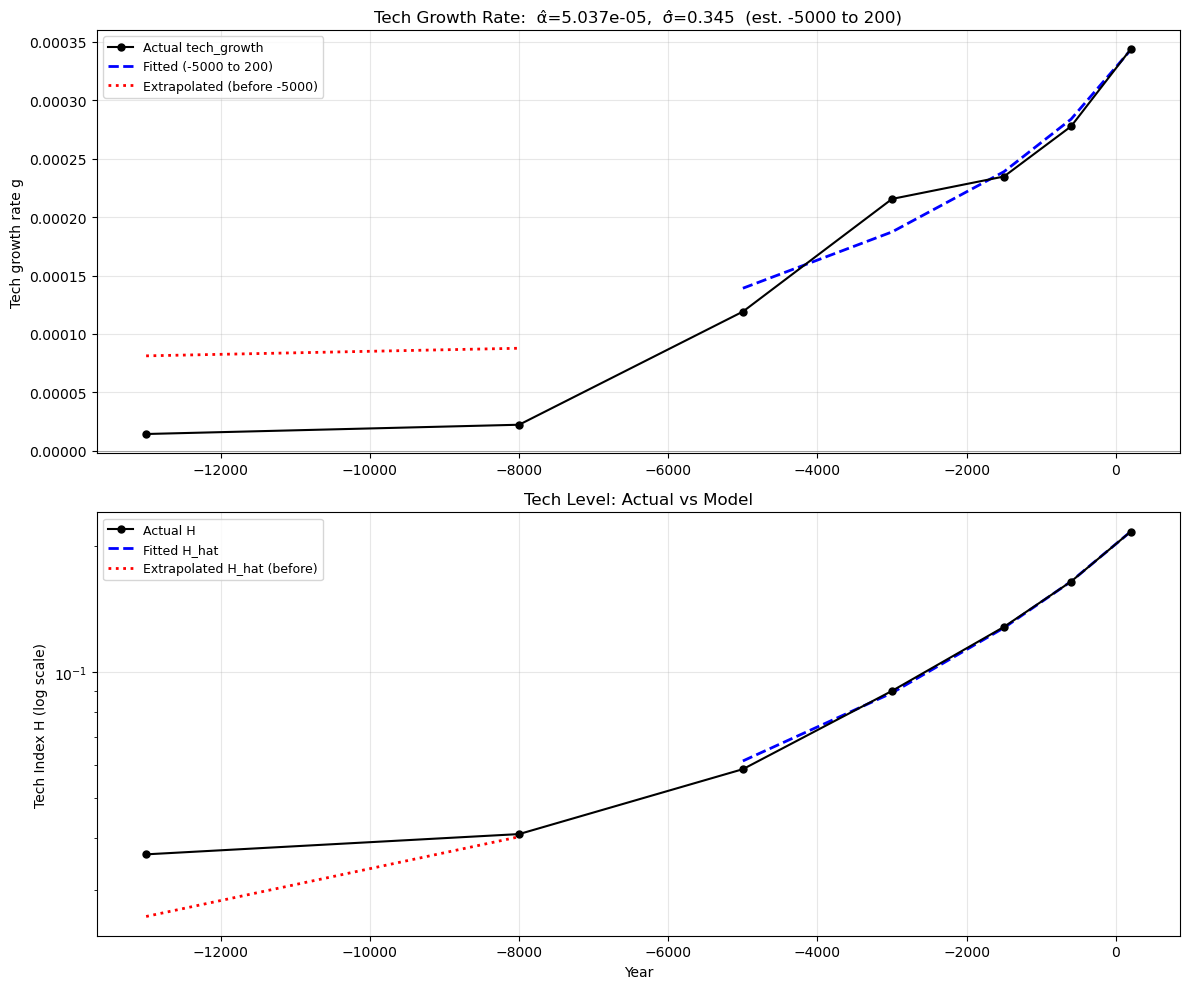

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [21]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=200, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=200, 
                               anchor_year=200, show_plot=True)

That is:

$$
h_t = \frac{\dot H_t}{H_t} = 0.0000504\, P_t^{0.345}
$$

---

Note that it does not do well before agriculture. The accumulation of ideas was much slower before we had settled down to farm. 

And note that there is a small apparent burst of creativity at the start of the Bronze Age: the coming of bronze tools (and weapons), records, writing, and their bastard offspring of the state, with all of its society of domination, panoply. 

But otherwise, it seems to pretty much nail it. But it is not that two heads are twice as good as one. Instead, it is that two heads are the cube root of two as good as one, i.e.\ $\sqrt[3]{2}$ times as good.

However, when we widen our view things break down:

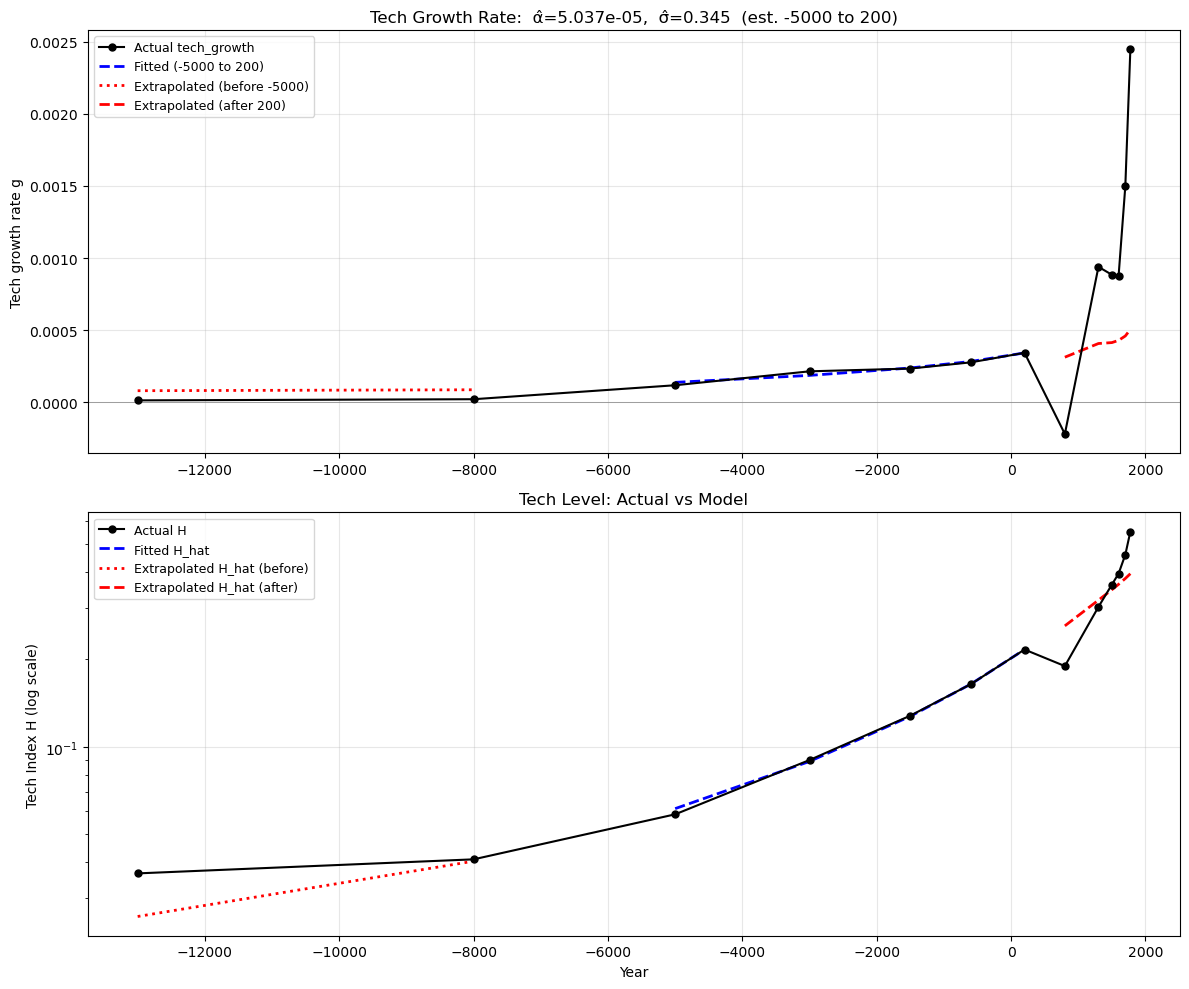

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [33]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=1775, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=1775, 
                               anchor_year=200, show_plot=True)

We see:

* a Late-Antiquity Pause;
* a Mediæval Catchup; and
* a Commercial-Imperial Age growth acceleration.

---

And when we widen it further: we see—well, one might well call it a "singularity", if one were to adopt the Silicon Valley vibe:

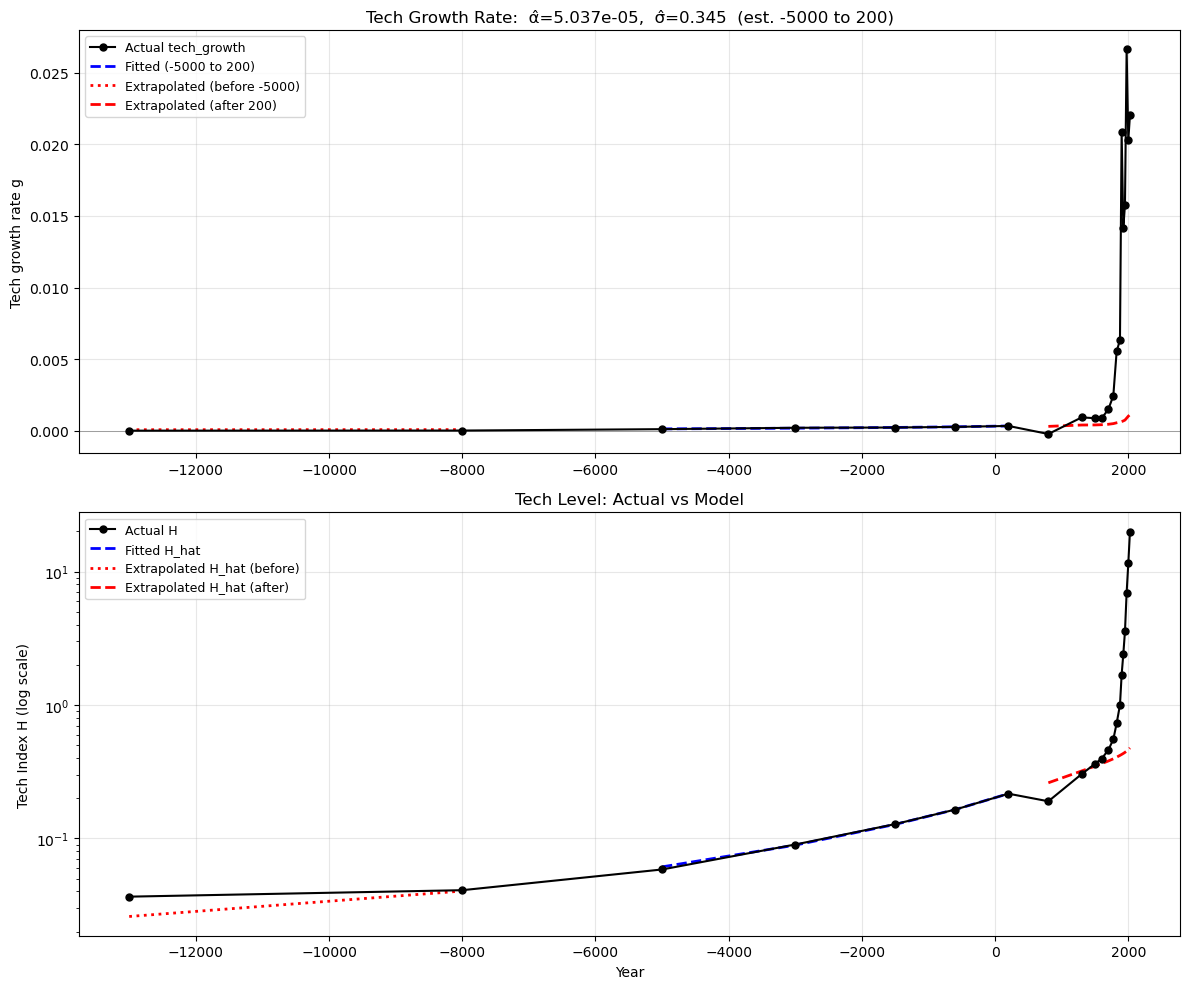

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [23]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=2025, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=2025, 
                               anchor_year=200, show_plot=True)

We see:

* an Industrial-Revolution explosion; and then the
* Modern Economic Growth miracle.

#### 1.2.2. Further Interpretation

We could have estimated our model over wide different ranges of start and end dates:

<img src="images/2026-03-31-alpha-and-sigma.png" />

checking the fit of 

$$
\begin{equation}
\ h_t = \frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

for starting years varying from -13000 to the development of writing, bronze, and the state in -3000; and from ending years from the classical-antiquity apogee in the year 200 on up to the start of the industrial revolution century in 1775.

Over what spans of time does this very simple “two heads are better than one, but stepping on toes” story look as if it might actually be a decent reduced form for what is going on in the data, rather than an *ex post* just‑so story? The answer, I think, is: over windows that are recognizably “agrarian” in both their demography and their technology—say, from the late Pleistocene/early Holocene up through classical times, but not for any period that includes history past the year-200 classical-antiquity apogee. When we estimate on windows like −13000 to −600, −13000 to 200, −8000 to −600, −8000 to 200, −5000 to −600, −5000 to 200, or −3000 to −600 and 200, we get α’s that are small but not absurd. We get σ’s that cluster in the ballpark of 0.3 to 0.5. More people do indeed appear to give you more ideas, but with substantial “stepping on toes” diminishing returns: discovery is not proportional to population, but to the square- or cube-root of population.

However, once we push the final year forward into 800 (at the end of the late-antiquity pause), 1300 (the high mediæval world), or 1600 or 1775 (into the commercial-imperial revolution age), however, the model starts vomiting up what we fed it. 

Including 800, we get σ very close to zero (as if population barely matters at all for ideas).

The computer is confronted with a world in technological regress **happened** after 200, but it was not because Pₜ had collapsed—there were still a lot of warm bodies around, The effective technological and organizational infrastructure inherited from classical antiquity suffered a very large negative shock: empires fragmented, long‑distance trade thinned out, cities shrank, literate bureaucracies downshifted to monasteries and courts, and the rate at which useful ideas were recombined and propagated slowed sharply, even as the number of brains available to recombine them remained high by pre‑Holocene standards. 

Trying to shoehorn that episode into a single hₜ = αPₜ^σ relationship is thus asking too much of the model. It tries to cope by declaring that population never mattered much for technology (σ ≈ 0, with α flexing to fit what variance it can).

Historically, what happened between 200 and 800 is not a continuation of “more people, slowly better ideas” but a regime shift in which institutional collapse, geopolitical fragmentation, and the loss (and later, slow reconstruction) of high‑productivity networks dominated the simple combinatorics of headcounts. In that sense, the year‑800 point is useful precisely because it breaks the model: it forces us to recognize that there are negative shocks to the effective idea‑generating and idea‑diffusing machinery—Dark Ages in the literal sense—that the two‑parameters‑and‑a‑power‑law approach cannot hope to capture

Suppose we were to push further, to 1300 or beyond? We get a σ well above one (as if more people lead to more than proportional idea growth). 

It is a fact that after 800 we got faster technological progress by a substantial margin than the -5000 to 200 experience would have led us to expect. Some of this was making up lost ground: redeploying social organization technologies that had vanished after the classical-antiquity apogee. Some of this was that mediæval civilizations were more creative with better potentials for information development than their predecessors. The computer sees these post-800 technological growth rates that are rapid relative to the -13000 to 200 experience, and so desperately reaches for a high value of σ to try to get as close to fitting those anomalous end-of-sample observations as it can. 

From the point of view of Pₜ, this is still recognizably an agrarian world: land is binding, agriculture dominates, cities are small. Population grows, sometimes quite briskly; by 1300 we are, in much of Eurasia, bumping along a relatively high preindustrial carrying capacity. If the simple Kremer story were the whole story—more people, more brains, more ideas—you would expect the 800–1500 centuries to give you parameter estimates that look like a modest extrapolation of the −5000 to 200 regime: σ somewhere between 0 and 1, α small but steady, and hₜ tracking Pₜ with some noise.

That is not what the EDA finds. Once you rope 800–1500 into the window, you are asking the model to digest at least three distinct phenomena with one little hₜ = αPₜ^σ mouthful: the slow post–Dark Age rebuild of Western Europe’s institutional and trade networks; the Mongol shock and its consequences for Eurasian integration; and then, in the back half of the period, the beginnings of what will become the commercial-imperial age, with Venice, Genoa, the Hanseatic League, and their analogues knitting together higher-velocity circuits for goods, people, and ideas. The result is parameter estimates that are telling you, politely but firmly, that population alone is no longer an adequate sufficient statistic for “idea production capacity”. Sometimes σ jumps toward or above 1, with an α so tiny that you are effectively fitting the upturns in hₜ by saying: only at very high Pₜ does this kick in—and even then the scale factor is microscopic. Sometimes σ wants to slide back toward the 0.3–0.5 agrarian comfort zone but can only do so by misfitting the mid-medieval “plateau and push” in your tech index.

In plainer language: 800–1500 is an era in which organizational, institutional, and geopolitical structures—the rise of commercial city-states, the spread of money economies, the (partial) reconstitution of long-distance trade, the beginnings of global exploration and extraction at the very end—start to matter a great deal for how effectively brains get marshaled into useful new ideas. The model thinks in terms of headcounts; the history is increasingly about networks and incentives. The fact that you can get a decent fit over −5000 to 200 and then watch the parameter pair go haywire as you extend the window to 1300 or 1500 is not a bug: it is the data tapping you on the shoulder and saying that by the high medieval period you are no longer in a world where “population → ideas” is the dominant channel. You are in a world where institutions, trade structures, and state systems have begun to amplify—or choke off—the combinatorics of brains in ways that a single power law in Pₜ cannot absorb. As an exploratory device, that is exactly what you want the exercise to do: signal where the simple story runs out of gas, and where you have to start writing down something closer to a political economy of innovation, not just a demography of it.

So the moral is: treat the “two heads, stepping on toes” formulation as a decent reduced form for the long, grinding agrarian ascent up to the classical plateau; once you attempt to absorb the late‑antiquity‑pause and its aftermath, the estimates themselves start waving red flags that you are now in the business of modeling institutional catastrophe and recovery, not just the arithmetic of brains and blueprints.

---
---

## 2. Why Are We Doing This?

Your reaction by now is almost surely: "This is overkill!" 

If so, you are right: this is overkill. We have only about 50 numbers to deal with. And yet we have fired up a substantial automated calculation and presentation apparatus. 

But, out in the real world, you all are going to be faced not with collections of 50 numbers, but collections of 5,000, or 5 million. And you will be helpless in their face if you do not have command of the basic data science EDA tools. 

Starting in 1775, human history underwent a phase shift with the beginnings of the British Industrial Revolution century and the emergence for the first time of GPTs: General Purpose Technologies. The first wave of steam-engine-coupled-to-automatic-textile machinery remade the human economy over the next hundred years. For 4/5 of the economy things get broadly better—potential productivity went up by maybe half—but things remained broadly recognizable. For 1/5 of the economy, things were utterly transformed by the GPT: productivity at the end in that slice affected was perhaps nine times what it had been at the start, but if you insisted in trying to do your job in the old way with the old tools, your income was at most a third that of your predecessors. Joseph Schumpeter called this capitalist creative destruction. He was right. We should probably call it capitalist engineering entrepreneurial creative destruction. But it was a very new thing in human history, and an important thing. 

It was a thing that became much more important after 1875. New GPTs emerged not every half century or so, but every decade, and the tripling of human technological capability took not a century, but rather 37 years or so. We have had four of these episodes since 1875. I call them applied-science, mass-production, globalized value-chain, and now info-bio tech-attention. But there are many other names, and you might here periodizations like: Belle-Époque, Social-Democratic, Neoliberal, and Post-Neoliberal. They are pointing at the same thing from different angles.

For you, personally, the current coming of info-bio tech-attention economy,= and society is especially noteworthy. Because this time, it is the jobs that you are best suited for that are in the bullseye of the Schumpeterian creative-destruction engineering-entrepreneurial-capitalist GPT process. Adapt. Or else. And a substantial part of your success at adaptation will depend on whether you are able to master the tools of literacy and numeracy in their future form or not. Starting now.

Thus learning jupyter notebooks and python may well turn out to be the intellectual equivalent for you of "eat your spinach": something that may seem unpleasant and unappetizing now, but that makes you stronger and more capable.

A couple of years ago, I had coffee with a student who had graduated in 2007, and who attributed a large chunk of the interesting and successful career he has had in the past decade-and-a-half years—had in spite of the collapse of the job market in 2008—to the fact that he had been fluent in Microsoft Office when he left Berkeley. But now, he said—and I agree—it is not fluency in Word, Powerpoint, and (shudder) Excel that allows one to make oneself useful in a white-collar organization doing interesting work while one learns-by-doing, it is rather fluency in a language like Python and the ability to script hooks into various Big Data and other APIs. 

An analogy: Back in the medieval European university, people would learn the Trivium—the 'trivial' subjects of Grammar (how to write), Rhetoric (how to speak in public), and Logic (how to think coherently)—then they would learn the Quadrivium of Arithmetic, Geometry, Music/Harmony, and Astronomy/Astrology; and last they would learn the advanced and professional subjects: Law or Medicine or Theology and Physics, Metaphysics, and Moral Philosophy.

But a student would also learn two more things: how to learn by reading—how to take a book and get something useful out of it, without a requiring a direct hands-on face-to-face teacher; and (2) how to write a fine chancery hand so that they could prepare their own documents, for submission to secular courts or to religious bishops or even just put them in a form where they would be easily legible to any educated audience back in those days before screens-and-attachments, before screens-and-printers, before typewriters, before printing.

In 1999 Python programming language creator Guido van Rossem compared the ability to read, write, and use software you had built or modified yourself to search and analyze data and information collections. Guido predicted that mass programming, if it could be attained, would produce increases in societal power and changes in societal organization of roughly the same magnitude as mass literacy has had over the past several centuries. Guido may be right, and he may be wrong. But what is clear is that your lives may be richer, and you may have more options, if the data science and basic programming intellectual tools become a useful part of your intellectual panoplies.

The Data Science tools may well turn out to be in the first half of the 2000s the equivalent of a _fine chancery hand_, just as a facility with the document formats and commands of the Microsoft office suite were the equivalent of a fine chancery hand at the end of the 1900s: practical, general skills that make you of immense value to most if not nearly all organizations. This—along with the ability to absorb useful knowledge without requiring hands-on person-to-person face-to-face training—will greatly boost your social power and your set of opportunities in your life.

If we are right about its value.

Why Jupyter and Python, rather than R-studio and R, or C++ and Matlab? 

Because Jupyter Project founder Fernando Perez has an office on the fourth floor of Evans. Because 40% of Berkeley undergraduates currently take Data 8 and so, taking account of other channels, more than half of Berkeley students are already going to graduate literonumerate in Python.

Is fluency in something like Python in particular and data-science tools in general is becoming, for the 21st Century, the equivalent of what learning to write a fine chancery hand was if you went to Oxford or Cambridge University in the 14th Century? We do not know. We do think we should help you get ready.

----

## 3. Jupyter Notebooks

This browser window is now showing you a computer science object that is called a "Jupyter notebook". A notebook is a place to write programs and view their results, and also to write text. The text and programs are contained in little boxes called "cells". When the computer thinks that you are paying attention to a particular cell—and may click in it, and then edit it—it surrounds the cell with a blue box, and puts a blue line to the left of the cell.

A notebook is an editable document object in which you can write computer programs; view their results; and comment, annotate, and explain what is going on. Project jupyter:

<<https://en.wikipedia.org/wiki/Project_Jupyter>> 

is headquartered here at Berkeley, where jupyter originator and ringmaster Fernando Pérez 
<<https://en.wikipedia.org/wiki/Fernando_Pérez_(software_developer)>> 

works: its purpose is to build human-friendly frameworks for interactive computing. If you want to see what Fernando looks and sounds like, you can load and watch a 15-minute inspirational video by clicking on the line 'YouTubeVideo("Wd6a3JIFH0s")' in the cell immediately below this one, and then clicking on the '▶' symbol in the toolbar at the top of the sub-window this cell appears in: 

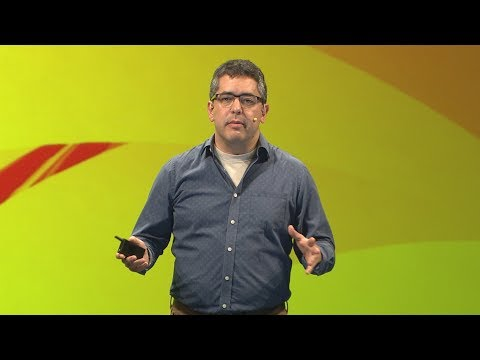

In [34]:
from IPython.display import YouTubeVideo

# The original URL is: 
# https://www.youtube.com/watch?v=Wd6a3JIFH0s

YouTubeVideo("Wd6a3JIFH0s")

### 3.1. Cells & Notebooks

#### 3.1.1. Code Cells

The _cell_ directly below this one contains one line of code in the Python 3 computer language. You _run_ this line as a program—the computer _executes_ the instructions the cell containss—when you click on the '▶' symbol in the toolbar at the top of this sub-window. (You could also have run the cell by, when the computer has focused on it by your clicking on it, pressing 'shift-return' or 'control-return' on your keyboard.) a code cell will execute all of the code it contains.

The line of type in the cell is a _Python expression_.
&nbsp;

Now try running this cell:

In [35]:
print("Hello, world!")

Hello, world!


and this one:

In [36]:
print("\N{WAVING HAND SIGN}, \N{EARTH GLOBE ASIA-AUSTRALIA}!")

👋, 🌏!


Every 'print' expression commands the computer to print a line of symbols to the screen. Directions as to what is in the line of symbols that it prints are contained between the '(' and the ')' that follow the initial Python command 'print' on the expression line.

The first of the two code cells above that you just ran is the standard first computer program to write, either if you are a new student or if you are testing out a new machine or testing out writing in a new programming language. it tells the computer to print out to the screen the symbols 'Hello, World!' What did the second code cell print to the screen, and why?

Within a code cell, each 'print' statement's output is printed to the screen on a separate line. The lines are arranged in the order in which the computer, scanning from the top to the bottom of the code cell, encounters the lines.

----

Remember the Fernando Perez video? Let's look back on its code cell:

This cell tells the computer to enlarge the set of Python commands it understands by finding the `YouTubeVideo` command in the `IPython.display` external library of commands, and then importing that command into its memory. Once it has done that, you can then ask the computer to execute that command—which then constructs a little YouTube video window and plays a YouTube video in it. You ask the computer to do so the in the fourth line of the code cell. Which YouTube video does the computer play? You tell it by writing, after `YouTubVideo` a `(`, then a `"`, then the reference ID of the video, then another `"`, and then, finally, a `'`.

Between the first and the last lines of the code cell are two lines that are _comment lines_. Anything on a line that comes after a `#` symbol inside a code cell the computer takes to be a comment—something directed at humans, and not at computers, that it should ignore. The comment lines tell you—us—what the URL is for the video that the fourth line is going to command the computer to play.

The cell also contains two blank lines. They are just there to give your eyes and brain visual clues to where to look for information, and thus make code cells easier to read.

----

In [ ]:
from IPython.display import YouTubeVideo

# The original URL is: 
# https://www.youtube.com/watch?v=Wd6a3JIFH0s

YouTubeVideo("Wd6a3JIFH0s")

#### 3.1.2 Text (Markdown) Cells
In a notebook, each rectangle containing text or code is called a *cell*.

Text cells (like this one) can be edited by double-clicking on them. They're written in a simple format created by Jon Gruber called **markdown** <<http://daringfireball.net/projects/markdown/syntax>> to add formatting and section headings. You almost surely want to learn how to use markdown.

After you edit a text cell, click the 'run cell' button at the top that looks like `▶` in the toolbar at the top of this window, or press 'shift-return' on your keyboard to confirm any changes to the text and formatting. 

**Question.** This paragraph is in its own text cell.  Try editing it so that this sentence is the last sentence in the paragraph, and then click the 'run cell' `▶` button or 'shift-return'. This sentence, for example, should be deleted. So should this one.

**Answer.** This paragraph is in its own text cell.  Try editing it so that this sentence is the last sentence in the paragraph, and then click the 'run cell' `▶` button or 'shift-return'.

----

#### 3.1.3. Writing notebooks

You can use Jupyter notebooks for your own projects or documents.  When you make your own notebook, you'll need to create your own cells for text and code.

To add a cell, click the + button in the menu bar.  It will start out as either a markdown text or a code cell.  You can change it to the other type by clicking inside it so it's highlighted, clicking the drop-down box to the left of 'Python 3' in the menu bar, and choosing either 'Code' or 'Markdown'.

&nbsp;

**Question** Add a code cell below this one.  Write code in it that prints out:
   
    A whole new cell! ♪🌏♪

(That musical note symbol is like the Earth symbol.  Its long-form name is 

`\N{EIGHTH NOTE}`

.)

Run your cell to verify that it works.

**Answer.**

In [37]:
print("A whole new cell! \N{EIGHTH NOTE} \N{EARTH GLOBE ASIA-AUSTRALIA} \N{EIGHTH NOTE}")

A whole new cell! ♪ 🌏 ♪


The expression 

`"A whole new cell! \N{EIGHTH NOTE} \N{EARTH GLOBE ASIA-AUSTRALIA} \N{EIGHTH NOTE}"` 

is just a string of symbols. The quotation marks at the start and the end tell Python that it is a string of symbols. Similarly, the expression 

`"a"`

is a (very short) string of symbols. What happens when we tell Python to print it?

In [38]:
print("a")

a


What if we take out the quotation marks?

In [39]:
# print(a)

----

#### 3.1.4. "Errors"

Python is a language, and like natural human languages, it has rules.  It differs from natural language in two important ways:

1. The rules are *simple*.  You can learn most of them in a few weeks and gain reasonable proficiency with the language in a semester.
2. The rules are *rigid*. If you're proficient in a natural language, you can understand a non-proficient speaker, glossing over small mistakes.  A computer running Python code is not smart enough to do that.

Whenever you write code, you'll make mistakes.  When you run a code cell that has errors, Python will sometimes produce error messages to tell you what you did wrong.

When you run code, you have the option to, in the window menubar, click 'Run > Run All Cells', which will run all the code cells in the notebook in order. However, the notebook stops running code cells if it hits an error.

We have made an error in the next code cell.  Run it and see what happens. Then correct it:

In [43]:
print("This line is missing something."

_IncompleteInputError: incomplete input (1867411798.py, line 1)

In [44]:
# **answer**

print("This line is missing something.")

This line is missing something.


In [45]:
Now it may not feel like an opportunity:

SyntaxError: invalid syntax (875454905.py, line 1)

**3.1.4.1. Dealing with Errors**: Errors are okay; even experienced programmers make many errors.  When you make an error, you just have to find the source of the problem, fix it, and move on. The first rule of computer programming: MAKING ERRORS IS NOT A PROBLEM. MAKING ERRORS IS AN OPPORTUNITY.

Now it may not feel like an opportunity:

<img style="display:block; margin-left:auto; margin-right:auto;" src="2026-05-05-confronting-unexpected-behavior.png" alt="Durin's Bane: Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame" title="Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame" border="0" width="750" />

Here we have Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame.

It usually is not that bad. But it is bewildering

**3.1.4.2. The Kernel**: The kernel is a program that executes the code inside your notebook and outputs the results. In the top right of your window, you can see a circle that indicates the status of your kernel. If the circle is empty (⚪), the kernel is idle and ready to execute code. If the circle is filled in (⚫), the kernel is busy running some code. 

Next to every code cell, you'll see some text that says 'In [...]'. Before you run the cell, you'll see 'In [ ]'. When the cell is running, you'll see 'In [*]'. If you see an asterisk (\*) next to a cell that doesn't go away, it's likely that the code inside the cell is taking too long to run, and it might be a good time to interrupt the kernel (discussed below). When a cell is finished running, you'll see a number inside the brackets, like so: 'In [1]'. The number corresponds to the order in which you run the cells; so, the first cell you run will show a 1 when it's finished running, the second will show a 2, and so on. 

You may run into problems where your kernel is stuck for an excessive amount of time, your notebook is very slow and unresponsive, or your kernel loses its connection. If this happens, try the following steps:

1. At the top of your screen, click **Kernel**, then **Interrupt**.
2. If that doesn't help, click **Kernel**, then **Restart**. If you do this, you will have to run your code cells from the start of your notebook up until where you paused your work.
3. If that doesn't help, restart your server. First, save your work by clicking **File** at the top left of your screen, then **Save and Checkpoint**. Next, click **Control Panel** at the top right. Choose **Stop My Server** to shut it down, then **Start My Server** to start it back up. Then, navigate back to the notebook you were working on. You'll still have to run your code cells again.

**3.1.4.3. What Sorcery Is This?:** Back in J.R.R. Tolkien's "The Lord of the Rings", when the wizard Gandalf the Grey runs into problems, occasionally he feels he has to spill his guts to the uncomprehending non-wizards around him. Hence this passage:

> "“I found myself suddenly faced by something that I have not met before. I could think of nothing to do but to try and put a shutting-spell on the door. I know many; but to do things of that kind rightly requires time, and even then the door can be broken by strength. ‘As I stood there I could hear orc-voices on the other side: at any moment I thought they would burst it open. I could not hear what was said; they seemed to be talking in their own hideous language. All I caught was ghâsh: that is’“fire’. Then something came into the chamber – I felt it through the door, and the orcs themselves were afraid and fell silent. It laid hold of the iron ring, and then it perceived me and my spell.

> "What it was I cannot guess, but I have never felt such a challenge. The counter-spell was terrible. It nearly broke me. For an instant the door left my control and began to open! I had to speak a word of Command. That proved too great a strain. The door burst in pieces. Something dark as a cloud was blocking out all the light inside, and I was thrown backwards down the stairs. All the wall gave way, and the roof of the chamber as well, I think. I am afraid Balin is buried deep, and maybe something else is buried there too. I cannot say. But at least the passage behind us was completely blocked. Ah! I have never felt so spent, but it is passing..."

Listening in to computer programmers discuss errors and how to fix them, you may well feel like the uncomprehending hobbits listening to the wizard Gandalf here.  But you are in a better position than your predecessors. **This is a place where large language models are genuinely useful**, for their training data contains a lot of examples of computer programmers finding bugs in analogous situations to whatever one you are in, and then making good guesses as to how to correct them. 

And do not get too distracted by the leaning-in to the "sorcery" metaphor that you encounter, as you will:

> Computational processes are abstract beings that inhabit computers.
As they evolve, processes manipulate other abstract things called data.

> the evolution of a process is directed by a ptern of rules called a program. People create programs to direct processes. In eﬀect, we conjure the spirits of the computer with our spells.

> A computational process is indeed much like a sorcerer’s idea of a
spirit. It cannot be seen or touched. It is not composed of matter at all. However, it is very real. It can perform intellectual work. It can answer questions. It can aﬀect the world by disbursing money at a bank or by controlling a robot arm in a factory. The programs we use to conjure processes are like a sorcerer’s spells. They are carefully composed from symbolic expressions in arcane and esoteric programming languages that prescribe the tasks we want our processes to perform.

> A computational process, in a correctly working computer, executes
programs precisely and accurately. Thus, like the sorcerer’s appren-
tice, novice programmers must learn to understand and to anticipate
the consequences of their conjuring. Even small errors (usually called
bugs or glitches) in programs can have complex and unanticipated con-
sequences. Fortunately, learning to program is considerably less dangerous than learning sorcery, because the spirits we deal with are conveniently contained in a secure way. Real-world programming, however, requires care, expertise, and wisdom. A small bug in a computer-aided design program, for example, can lead to the catastrophic collapse of an airplane or a dam or the self-destruction of an industrial robot...

---

### 3.2. Libraries

There are many add-ons and extensions to the core of python that are useful—indeed essential—to using it to get work done. They are contained in what are called libraries. The rest of this notebook needs three libraries. So let us tell the python interpreter to install them. Run the code cell below to do so: 

In [47]:
# install the numerical python, python data analysis, and mathematical
# plotting libraries for python

!pip install numpy
!pip install pandas
!pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib as mpl

----

### 3.3. Python: Numbers & Variables

#### 3.3.1. Variables

Remember our line that went wrong: `print(a)`? The Python interpreter kernel burped up an error. It said "name is not defined". What does this mean? It means that, without the quotation marks telling Python the a is a string, it thought that the a was the name of something—a variable. But it wasn't. So it did not know what to do.

Let's fix that:

In [48]:
a = "Hello, World!"

This is an *assignment* statement. It assigns whatever is on the right of the equals sign as the *value* of what the name on the left is.

Now what do you think will happen if we tell Python to

`print(a)`

?

In [49]:
print(a)

Hello, World!


In [50]:
# **answer**

print(a)

Hello, World!


----

Suppose that we assign something else to a?

In [51]:
a = 3.25
print(a)

a = 6.02 * 10**23
print(a)

a = 1 * 2 * 3 * 4 * 5 * 6 * 7 * 8 * 9 * 10
print (a)

3.25
6.019999999999999e+23
3628800


**Note**: If, on the last line of a cell, we leave off the `print`:

In [52]:
a

3628800

When you run a notebook cell, if the last line has a _value_, then Jupyter helpfully prints out that value for you. However, it won't print out prior lines automatically:

In [53]:
print(2)
3
4

2


4

Above, you should see that 4 is the value of the last expression, 2 is printed because it is within the scope of the print command, but 3 is lost forever because it was neither printed nor last.

----

In natural language, we have terminology that lets us quickly reference very complicated concepts.  We don't say, "That's a large mammal with brown fur and sharp teeth!"  Instead, we just say, "Bear!"

In Python, we do this with *assignment statements*. An assignment statement has a name on the left side of an '=' sign and an expression to be evaluated on the right.

----

#### 3.3.2. Arithmetic
The line in the next cell subtracts.  Its value is what you'd expect.  Run it:

In [54]:
3.25 - 1.5

1.75

Many basic arithmetic operations are built into Python.  The textbook section on [Expressions](http://www.inferentialthinking.com/chapters/03/1/expressions.html) describes all the arithmetic operators used in the course.  The common operator that differs from typical math notation is '\*\*', which raises one number to the power of the other. **NOT '^'.** Thus '2**3' stands for $2^3$ and evaluates to 8. 

The order of operations and parentheses is the same as what you learned in elementary school. For example, compare:

In [55]:
3+6*5-6*3**2*2**3/4*7

-723.0

to:

In [56]:
4+(6*5-(6*3))**2*((2**3)/4*7)

2020.0

In standard math notation, the first expression is

>$3 + 6 \times 5 - 6 \times 3^2 \times \frac{2^3}{4} \times 7$,

while the second expression is

>$3 + (6 \times 5 - (6 \times 3))^2 \times (\frac{(2^3)}{4} \times 7)$.

There are some things to beware of in Python with respect to the standard arithmetic symbols:

In [57]:
print("2+2 =", 2+2)
print("'2'+'2' =", "2"+"2")

2+2 = 4
'2'+'2' = 22


If the designers of Python had been ruthlessly pedantic, they might have made us write

    define the name ten to hereafter have the value of 3 * 2 + 4 

instead.  You will probably appreciate the brevity of `=`! But keep in mind that this is the real meaning. `=` does not assert or declare that what is on the left is equal to whqt is on the right. Rather, it takes what is on the right and stuffs it into the metaphorical box which has the name on the left.

Suppose that you do want to use the equals sign in the normal way? You have to use `==`. Here is an example:

In [58]:
a = 4

if (a == 4): 
  print("everything is ok")
else:
  print("something is wrong!")

everything is ok


In [59]:
a = 3

if (a == 4): 
  print("everything is ok")
else:
  print("something is wrong!")

something is wrong!


In [60]:
a = 4

# if (a == 4): 
#  print("everything is ok")
#else:
#  print("something is wrong!")

----

A common pattern in Jupyter notebooks is to assign a value to a name and then immediately evaluate the name in the last line in the cell so that the value is displayed as output. 

In [61]:
close_to_pi = 355/113
close_to_pi

3.1415929203539825

Another common pattern is that a series of lines in a single cell will build up a complex computation in stages, naming the intermediate results.

In [62]:
semimonthly_salary = 841.25
monthly_salary = 2 * semimonthly_salary
number_of_months_in_a_year = 12
yearly_salary = number_of_months_in_a_year * monthly_salary
yearly_salary

20190.0

Names in Python can have letters (upper- and lower-case letters are both okay, and count as different letters), underscores, and numbers.  The first character can't be a number (otherwise a name might look like a number).  And names can't contain spaces, since spaces are used to separate pieces of code from each other.

Other than those rules, what you name something doesn't matter *to Python*.  For example, this cell does the same thing as the above cell, except everything has a different name:

In [63]:
a = 841.25
b = 2 * a
c = 12
d = c * b
d

20190.0

**However**, *names are very important for making your code readable* to yourself and others.  The cell above is shorter, but it's totally useless without an explanation of what it does.

----

### 3.3.3. Lists

Lists and their siblings, numpy arrays, are ordered collections of objects that have an order. Lists allow us to store groups of variables under one name. The order then allows us to access the objects in the list for easy access and analysis. If you want an in-depth look at the capabilities of lists, take a look at <<https://www.tutorialspoint.com/python/python_lists.htm>>

To initialize a list, you use brackets. Putting objects separated by commas in between the brackets will add them to the list. For example, we can create and name an empty list:

In [64]:
list_example = []
print(list_example)

[]


We can add an object to the end of a list:

In [65]:
list_example = list_example + [5]
print(list_example)

[5]


Now we have a one-element list. And we can add another element:

In [66]:
list_example = list_example + [10]
print(list_example)

[5, 10]


to make a two-element list.

We can join—"concatenate"—two lists together:
    

In [67]:
list_example_two = list_example + [1, 3, 6, 'lists', 'are', 'fun', 4]
print(list_example_two)

[5, 10, 1, 3, 6, 'lists', 'are', 'fun', 4]


>**Digression**: It is, I think, a mistake for python to use '+' in this way. In arithmetic, '+' is simply addition. With lists, '+' smashes the two lists on either side together to make a bigger list. this 'overloading' of '+' can be a source of great confusion. For example:

In [68]:
# overloading of the `+` operator considered harmful:

four = 4
print(" This '4' is a number:", four, "; so '+' is addition \n and so", four, "+", four, "=", 
      four + four)

four = [4]
print("\n This '4' is a list:", four, "; so '+' is list concatenation \n and so", four, "+", four, "=", 
      four + four)

four = '4'
print("\n Even worse is: this '4' is a string-of-symbols: \n", four, "; so '+' is symbol concatenation \n and so", four, "+", four, "=", 
      four + four)

 This '4' is a number: 4 ; so '+' is addition 
 and so 4 + 4 = 8

 This '4' is a list: [4] ; so '+' is list concatenation 
 and so [4] + [4] = [4, 4]

 Even worse is: this '4' is a string-of-symbols: 
 4 ; so '+' is symbol concatenation 
 and so 4 + 4 = 44


To access not the list as a whole but an individual value in the list, simply count from the start of the list, and put the place of the object you want to access in brackets after the name of the list. 

**But you have to start counting from not one but zero.** 

Thus the initial object of a list has index 0, the second object of a list has index 1, and in the list above the eighth object has index 7:

In [69]:
selected_example = list_example_two[7]
print(selected_example)

fun


which is indeed the eighth item of 'list_example_two'.

You may have noticed already that lists do not have to be made up of elements of the same kind. 

Indices do not have to be taken one at a time, either. Instead, we can take a 'slice;\' of indices, and return the elements at those indices as a separate list. 

Suppose we just want to select out items 4 through 6 from a list. We can do so:

In [70]:
selected_list = list_example_two[4:7]
print(selected_list)

[6, 'lists', 'are']


We can select out the largest and smallest items of a list via `min` and `max`:

In [71]:
# A list containing six integers.
a_list = [1, 6, 4, 8, 13, 2]

# Another list containing six integers.
b_list = [4, 5, 2, 14, 9, 11]

print('Max of a_list:', max(a_list))
print('Min of b_list:', min(a_list))

Max of a_list: 13
Min of b_list: 1


Numpy arrays are siblings of lists that can be operated on arithmetically with much more versatility than regular lists. Let us start by making an array that consists of the numbers from zero to nine:

In [72]:
import numpy as np

example_array = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print("Example Array:", example_array)

Example Array: [0 1 2 3 4 5 6 7 8 9]


This could have been accomplished more quickly:

In [73]:
example_array_2 = np.arange(10)
print('Another Example Array: ', example_array_2)

Another Example Array:  [0 1 2 3 4 5 6 7 8 9]


Multiplying a list and an array by a number produce different results:

In [74]:
b_list = [4, 5, 2, 14, 9, 11]
print('Multiplying a list by 2: ', 2 * b_list)

b_array = np.array([4, 5, 2, 14, 9, 11])
print('Multiplying an array by 2: ', 2 * b_array)

Multiplying a list by 2:  [4, 5, 2, 14, 9, 11, 4, 5, 2, 14, 9, 11]
Multiplying an array by 2:  [ 8 10  4 28 18 22]


----

## 4. Programming

### 4.1. Looping

Loops <<https://www.tutorialspoint.com/python/python_loops.htm>> are  useful in manipulating, iterating over, or transforming large lists and arrays. The __for loop__ is useful in that it travels through a list, performing an action at each element. The following code cell moves through every element in example_array, adds it to the previous element in example_array, and copies this sum to a new array.

In [75]:
# calculating the labor force for the next 100 years

Labor_Force = []
L = 1
n = .01

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)

print(Labor_Force)

[1, 1.01, 1.0201, 1.030301, 1.04060401, 1.0510100501, 1.061520150601, 1.0721353521070098, 1.08285670562808, 1.0936852726843609, 1.1046221254112045, 1.1156683466653166, 1.1268250301319698, 1.1380932804332895, 1.1494742132376223, 1.1609689553699987, 1.1725786449236986, 1.1843044313729356, 1.196147475686665, 1.2081089504435316, 1.220190039947967, 1.2323919403474468, 1.2447158597509214, 1.2571630183484306, 1.269734648531915, 1.282431995017234, 1.2952563149674063, 1.3082088781170804, 1.3212909668982513, 1.334503876567234, 1.3478489153329063, 1.3613274044862353, 1.3749406785310978, 1.3886900853164088, 1.402576986169573, 1.4166027560312686, 1.4307687835915812, 1.445076471427497, 1.4595272361417722, 1.47412250850319, 1.4888637335882218, 1.503752370924104, 1.5187898946333451, 1.5339777935796786, 1.5493175715154754, 1.5648107472306303, 1.5804588547029366, 1.596263443249966, 1.6122260776824657, 1.6283483384592905, 1.6446318218438833, 1.6610781400623222, 1.6776889214629456, 1.694465810677575, 1.71

The most important line in the above cell is the 'for i in...' line. This statement sets the structure of our  loop, instructing the machine to stop at every number in `range(11)`, perform the indicated operations, and then move on. Once Python has stopped at every element in `range(11)`, the loop is completed and the final line, which outputs `Labor_Force`, is executed.

Now let us do a little magic

In [76]:
# calculating the labor force for the next 100 years

import pandas as pd

Labor_Force = []
L = 1
n = .01

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)

pd.DataFrame(Labor_Force).plot(title = "Labor Force", 
    xlabel = "Year", ylabel = "Value")

<Axes: title={'center': 'Labor Force'}, xlabel='Year', ylabel='Value'>

In [77]:
# calculating the labor force and the efficiency-of-labor for the next 100 years

Year = []

Labor_Force = []
L = 10
n = 0.01

Efficiency_of_Labor = []
E = 10
g = 0.02

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)
    Efficiency_of_Labor = Efficiency_of_Labor + [E]
    E = E * (1 + g)
    Year = Year + [i]

pd.DataFrame([Year, Labor_Force, Efficiency_of_Labor]
    ).transpose().plot()

<Axes: >

In [78]:
pd.DataFrame([Year, Labor_Force, Efficiency_of_Labor]
    ).transpose().plot(
    title = "Growth Model Variables", xlabel = "Year", 
    ylabel = "Value", legend = 0)

<Axes: title={'center': 'Growth Model Variables'}, xlabel='Year', ylabel='Value'>

## 5 Reflection

Do not let any of this scare you. It is about building tools so that you can think better. And, at the bottom, all we are doing is counting things—but doing so by standing on the shoulders of giants, who have figured out how to enable us to count things in incredibly compressed, incredibly powerful ways.

Listen to physicist Richard Feynman explain how his QED model of light-matter interactions is simply counting things—adding up all the possible different ways a photon might interact with an electron—by analogy:

>“An analogy.... The Maya Indians were interested in... [the War-Star] Venus.... To make calculations, the Maya had invented a system of bars and dots to represent numbers... and had rules by which to calculate and predict not only the risings and settings of Venus, but other celestial phenomena.... Only a few Maya priests could do such elaborate calculations.... Suppose we were to ask one of them how to do just one step in the process of predicting when Venus will next rise as a morning star—subtracting two numbers..... How would the priest explain?....
 
>He could either teach us the... bars and dots and the rule... or he could tell us what he was really doing: ‘Suppose we want to subtract 236 from 584. First, count out 584 beans and put them in a pot. Then take out 236 beans and put them to one side. Finally, count the beans left in the pot. That number is the result....’ You might say, ‘My Quetzalcoatl! What tedium... what a job!’ To which the priest would reply, ‘That’s why we have the rules.... The rules are tricky, but they are a much more efficient way of getting the answer.... We can predict the appearance of Venus by counting beans (which is slow, but easy to understand) or by using the tricky rules (which is much faster, but you must spend years in school to learn them)’...

Python is the equivalent of learning a bunch of such rules, and practicing applying them.

----

# <font color="880000"> Lecture Notes: The Solow Growth Model </font>

## <font color="880000"> 1. Brief Reflections on Model Building </font>

### <font color="000088"> 1.1. Building Blocks </font>

As is the case with all economic models, the Basic Solow Growth Model consists of:

* _Variables_: economic quantities of interest that we can calculate and  measure, denoted by letters (or maybe two letters) like L for the number of workers in the labor force or Y for the amount of useful goods and services produced in a year—real GDP.

* _Behavioral relationships_: relationships that (1) describe how humans, making economic decisions given their opportunities and opportunity costs, decide what to do, and (2) that thus determine the values of the economic variables, represented by equations that have an economic variable on the left hand side and, on the right, a set of factors that determine the value of the variable and a rule of thumb for what that value is currently.

   * _Parameters_: determine which out of a broad family of potential behavioral relations describes the behavior of the particular economic scenario at hand; the ability to work algebraically with parameters allows one to perform an enormous number of potential "what-if?" calculations very quickly and in a very small space

* _Equilibrium conditions_: conditions that tell us when the economy is in a position of balance, when some subset of the variables are "stable"—that is, are either constant are changing in simple and predictable ways, usually represented by solutions of some system of the equations that are behavioral relationships.

* _Accounting identities_: statements about the relationships between variables that are automatically and necessarily true because of the way the variables are defined, represented by equations. 

&nbsp;

### <font color="000088"> 1.2. The Key to the Model </font>

In the case of the Solow growth model, the key variable is the capital intensity of the economy, which we will write using a lower-case Greek letter kappa: $ \kappa $. We measure $ \kappa $ as the ratio of the capital stock of the economy $ K $, to the level of output and income $ Y $. 

In every economic model economists proceed with their analysis by looking for an equilibrium: a point of balance, a condition of rest, a state of the system toward which the model will converge over time. Economists look for equilibrium for a simple reason: either an economy is at its (or one of its) equilibrium position(s), or it is moving—and probably (or hopefully?) moving rapidly—to an equilibrium position. The Solow growth model is no exception.

Once economists have found the equilibrium position toward which the economy tends to move, they then understand how the model will behave. And, if they have built the right model, it will tell you in broad strokes how the economy will behave.

In the Basic Solow Growth Model, the equilibrium economists look for is an equilibrium in which the economy’s capital-output ratio $ \kappa $ is contant, and thus the capital stock per worker, the level of income and output per worker, and the efficiency of labor are all three growing at exactly the same proportional rate—a rate that remains constant over time. We will call this rate g, for growth.

Is this going by at bewildering speed? Blame it on the fact that our curriculum here in Economics is not well-designed. We want you to have the tools of economic theory to use here in this course. But we don't have time to build them from scratch. So we skate over the surface—providing a quick review to those of you who have taken Econ 100b before, and a skating-over-the-surface to those of you who have not.

Remember: we do not want you to understand the conclusions of these models and theories—we merely want you to know those conclusions, take them for now on faith, and use them.

----

As my teacher's teacher, the Nobel Prize-winning economic historian Robert Fogel once said, the killer app of history (and economics) is counting things.

Math is basically all about counting things. But we are very lucky, in that we stand on the shoulders of giants who have figured out how to and transmitted to us the knowledge of how to count things in incredibly powerful ways.

One such giant whose shoulders we stand on is Muḥammad ibn Mūsā al-Khwārizmī (c. 780-850). The first part of his name is simply "Muhammad, son of Moses". The second part? It is the answer to the question: "OK. But which Muḥammad ibn Mūsā wandering around Baghdad in the early 800s during the reign of the Kalif al-Mamun are we talking about?” The answer was: "the one who came here from Khwārizm, and who works at the House of Wisdom established by the Kalif".

When Italians heard "al-Khwārizmī", they mangled it into **algorithm**. Every time you say **algorithm**, you are saying that you are undertaking the kind of step-by-step analysis that Muḥammad ibn Mūsā al-Khwārizmī taught us to do. Hew as the author of: _Al-Kitāb al-Mukhtaṣar fī Hisāb al-Jabr wa’l-Muḳābala—The Compendious Book on Calculation by Completion and Balancing_

<img src="images/al-khwarezmi.png" width="600" />

It was his work on how to repeatedly and rapidly do large numbers of similar and related calculations that allowed us to turn simple counting into the mathematics of "what-if?" machines. We ask the question "what-if?" And we then answer it be doing a large number of calculations about what might be at once, seeing which of these calculations produce ansers that satisfy whatever the consistency and coherence conditions we have imposed are, and then summarizing the results of all of them in a very small space. It becomes complicated and very hard to remember and opaque very quickly. But, at the bottom, it is just counting.

Listen to physicist Richard Feynman, about how his QED theory of the interaction of light and matter—a theory that has been tested and is correct at unbelievably precise scales. As of 1985:

>Experiments have Dirac's number at 1.00115965221 (with an uncertainty of about 4 in the last digit); the theory puts it at 1.00115965246 (with an uncertainty of about five times as much). To give you a feeling for the accuracy of these numbers, it comes out something like this: If you were to measure the distance from Los Angeles to New York to this accuracy, it would be exact to the thickness of a human hair...

No doubt experiments and calcuations since have sharpened both of those, and they are still in agreement.

Feynman, talking about this "Feynman Diagram" theory of his, said:

>An analogy…. The Maya Indians were interested in… [when they would be able to see the War-Star] Venus…. To make calculations, the Maya had invented a system of bars and dots to represent numbers… and had rules by which to calculate and predict not only the risings and settings of Venus, but other celestial phenomena….

>Only a few Maya priests could do such elaborate calculations…. 

>Suppose we were to ask one of them how to do just one step in the process of predicting when Venus will next rise as a morning star—subtracting two numbers….. How would the priest explain?….

>He could either teach us the… bars and dots and the rule… or he could tell us what he was really doing: 

>>Suppose we want to subtract 236 from 584. First, count out 584 beans and put them in a pot. Then take out 236 beans and put them to one side. Finally, count the beans left in the pot. That number is the result…. 

>You might say, ‘My Quetzalcoatl! What tedium… what a job!’ 

>To which the priest would reply,

>>That’s why we have the rules…. The rules are tricky, but they are a much more efficient way of getting the answer…. We can predict the appearance of Venus by counting beans (which is slow, but easy to understand) or by using the tricky rules (which is much faster, but you must spend years in school to learn them)...

We stand on the shoulders of myriad upon myriad of armies of giants. All we have to do is to build in our brains a filing system so we can remember how to utilize the conclusions of all the work they have gifted us with, trusting that they were indeed giants and knew how to do their job.

----

## <font color="880000"> 2. The Basics of the Model </font>

### <font color="000088"> 2.1. Preliminaries </font>

#### <font color="008800"> 2.1.1. The Labor Force and the Efficiency-of-Labor </font>

If the labor force L were constant and technological and organizational progress plus education that add to the efficiency-of-labor E were non-existent, we could immediately move on. But the economy’s labor force grows as more people turn 18 or so and join the labor force than retire, and as immigrants continue to arrive. And the efficiency of labor rises as science and technology progress, people keep thinking of new and more efficient forms of business organization, and people go to school and learn on the job

We assume—once again making a simplifying leap—that the economy’s labor force L's proportional rate $ g_L $ is a constant n. 

Note that n is not the same across countries. Note that it can and does shift over time in any one country. Since we want to tackle simple cases first, our background assumption will be that n is constant now as far as we can see into the future. But we will drop and vary this when we want to. 

Thus between this year and the next the labor force grows according to the formula:

>(2.1.1) $ \frac{dL}{dt} = g_LL = nL $

Next year’s labor force will thus be n percent higher than this year’s labor force.

We also assume—once again making a simplifying leap—that the economy’s efficiency of labor E's proportional growth rate g is a constant every year. Note that g is not the same across countries. Note that it can and does shift over time in any one country. But we want to tackle simple cases first. A constant efficiency-of-labor growth rate g is simple. Thus our background assumption will be that g is constant as far as we can see into the future. Then between this year and the next the efficiency of labor grows according to the formula:

>(2.1.2) $ \frac{dE}{dt} = gE $

&nbsp;

In [ ]:
# CODE CELL: GAINING INTUITION FOR n & g & L AND E
#
# getting a sense of how the Solow growth model
# works...
#
# what are the implications of saying that the
# labor force L increases at a gross rate n?
# Or that the efficiency-of-labor E increases
# at a growth rate g? or that the elasticity
# of output Y with respect to the economy's
# capital-intensity κ is a parameter θ?
# these code cells are for you to experiment,
# and find out. they set out simple finger
# exercises for you to investigate.
#
# this code cell allows you to explore what
# various values for the parameters n and g
# (and also initial values L_0 and E_0) really
# mean.
#

# ----
# BEGIN BLOCK
#
# change the right-hand-sides of the equations 
# in this block to what you wish. simply substitute 
# your own choices of values for L_0, n, E_0, 
# g, and the length T of the period you want 
# to examine. then execute this code cell, and
# see what results: 

T = 100

L_0 = 4
n = 0.02
E_0 = 1
g = 0.00

# END BLOCK
# ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_series = [L_0]
E_series = [E_0]
L = L_0
E = E_0

for i in range(T):
    L = L * (1 + n)
    E = E * (1 + g)
    L_series = L_series + [L]
    E_series = E_series + [E]

n_and_g_df = pd.DataFrame()
n_and_g_df['Labor Force'] = L_series
n_and_g_df['Efficiency of Labor'] = E_series

ax = n_and_g_df.plot()
ax.set_title("Labor Force and Efficiency of Labor")
ax.set_xlabel("Date")
ax.set_ylabel("Value")

plt.show()

#### <font color="008800"> 2.1.2. The Production Function </font>

The three behavioral relationship in the Basic Solow Growth Model is the production function: the relationship between the economy's level of income and production $ Y $ and its three determinants: the labor force $ L $, the efficiency of labor $ E $, and the economy's capital-intensity $ \kappa $, which is measured by the quotient of the economy's capital stock $ K $ and its level of income and production $ Y $:

>(2.1.3) $ \kappa = \frac{K}{Y} $

&nbsp;

**2.1.2.1. Satisfy Three Rules of Thumb**: We want this behavioral relationship to satisfy three rules of thumb:

1. A proportional increase in the economy's capital intensity $ \kappa = K/Y $, measured by the capital stock divided by total production, will carry with it the same (smaller) proportional increase in income and production no matter how rich and productive the economy is. A 1% increase in capital intensity will always increase income and production by the same proportional amount. 

2. If two economies have the same capital intensity, defined as the same capital-output ratio $ \kappa $, and have the same level of technology- and organization-driven efficiency-of-labor $ E $, then the ratio of their levels of total income and output will be equal to the ratio of their labor forces $ L $.

3. If two economies have the same capital intensity, defined as the same capital-output ratio $ \kappa $, and have the same labor forces, then the ratio of their levels of income and output will be equal to the ratio of their technology- and organization-driven efficiencies-of-labor $ E $.

There is one and only one way to write an algebraic expression that satisfies these two rule-of-thumb conditions. It is:

>(2.1.4) $ Y = \kappa^\theta E L  $

or with a lower-case $ y $ denoting income and production per worker:

>(2.1.5) $ y = \kappa^\theta E $

&nbsp;

>**Note**: You might object that this is circular: output and income $ Y $ depend on capital intensity $ \kappa $ defined as the capital-output ratio $ K/Y $, but how can you calculate $ \kappa $ and thus calculate $ Y $ when you need to know $ Y $ to calculate $ \kappa $? If this worries you, you could start elsewhere, with a different-looking production function:

>>(2.1.6) $ Y = K^\alpha (E L)^{1-\alpha} $

>Then divide both sides by $ Y^\alpha $:

>>(2.1.7) $ \frac{Y}{Y^\alpha} = \frac{K^\alpha}{Y^\alpha} (E L)^{1-\alpha} $

>>(2.1.8) $ Y^{1-\alpha} = \left(\frac{K}{Y}\right)^\alpha (E L)^{1-\alpha} $

>>(2.1.9) $ Y^{1-\alpha} = \kappa^\alpha (E L)^{1-\alpha} $

>>(2.1.10) $ Y^{\left(\frac{1-\alpha}{1-\alpha}\right)} = \kappa^{\left(\frac{\alpha}{1-\alpha}\right)} (E L)^{\left(\frac{1-\alpha}{1-\alpha}\right)} $

>>(2.1.11) $ Y = \kappa^{\left(\frac{\alpha}{1-\alpha}\right)} E L  $

>which is exactly the same as (2.1.4), once we define $ \alpha = \theta/(1+\theta) $ and thus $ \theta = \alpha/(1-\alpha) $. 

>>For historical reasons, every single other book uses $ \alpha $. Since $ \theta = \alpha/(1-\alpha) $, $\alpha = \theta/(1+\theta) $, and $ 1 - \alpha = \theta/(1+\theta) $, moving back and forth between the forms is not a problem. We will work with $ \theta $ as it produces simpler formulas.

&nbsp;

**2.1.2.2. Why These Rules of Thumb?**: Why did Robert Solow back in 1956 look for an algebraic formula for his production function that would satisfy these three rules-of-thumb? Economists like to simplify, ruthlessly, when they can get away with it. Rule-of-thumb (1) is a simplifying assumption: an intellectual bet that the process of aggregate economic growth is likely to look very similar as an economy goes from an income-per-capita level of 10,000 to 20,000 dollars per worker per year as when it goes from 40,000 to 80,000 dollars per worker per year. It is worth making only as long as that is in fact true—that the similarities in the aggregate overall economic growth process in different decades and at different income-per-worker levels outweigh the differences. If that were not or were to cease being the case, we should drop that rule-of-thumb assumption. So far, so good.

Rule-of-thumb (2) is simply that holding other things—capital intensity and efficiency-of-labor—constant, you can always duplicate what you are doing and produce and earn twice as much. Again, it is worth making only as long as that is in fact true, or approximately true. Again, so far, so good.

Rule-of-thumb (3) is a recognition that better-organized economies making better use of technology will be more productive: it is best thought of as a definition of how we are going to construct our quantitative index of the level of applied technological knowledge combined with efficient economic organization—the variable $ E $ that we call the efficiency-of-labor. It has no deeper implications.    


In [ ]:
# CODE CELL: GAINING INTUITION FOR Y & θ & κ
#
# this code cell allows you to explore what
# various values for the parameter θ mean for
# the relationship between Y and κ.
#
# choose your values for the efficiency-of-
# labor E, for the lafor force L; choose a 
# maximum value for capital-intensity κ and 
# a value for θ; or accept the values given
# in the block. then execute this code cell,
# and see what results:

# ----
# BEGIN BLOCK
#
# change the right-hand-sides of the equations 
# in this block to what you wish. simply substitute 
# your own choices of values for L, E, θ, and κ_{max}—
# the maximum capital-intensity you want to examine. 
# then execute this code cell, and see what results: 

L = 1
E = 10
κ_max = 50
θ = 1

# END BLOCK
# ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

κ_series = [0]
Y_series = [0]

for κ in range(κ_max):
    Y = κ**θ * E * L
    κ_series = κ_series + [κ]
    Y_series = Y_series + [Y]

Y_and_κ_df = pd.DataFrame()
Y_and_κ_df['capital_intensity'] = κ_series
Y_and_κ_df['production'] = Y_series

Y_and_κ_df.set_index('capital_intensity')

ax = Y_and_κ_df.production.plot()
ax.set_title("Production as a Function of Capital Intensity")
ax.set_xlabel("Capital Intensity")
ax.set_ylabel("Income and Production")
    
plt.show()

→→→→→→→→ point reached at end of 2022-01-25 lecture→→→→→

#### <font color="008800"> 2.1.3. Investment and Capital Accumulation </font>

Following economists' custom of ruthless simplification, assume that individuals, households, and businesses desire to save a fraction $ s $ of their gross income $ Y $, so that total savings are:

>(2.1.12) $ S = sY $

We call s the economy’s saving rate or, more completely, its saving-investment rate (to remind us that s is measuring both the flow of saving into the economy’s financial markets and also the share of total production that is invested and used to build up and increase the economy’s capital stock).

Assume that there are no problems in translating individuals', households', and businesses' desires to save some of their income $ Y $ into investment I:

>(2.1.13) $ I = S = sY  $

While the saving-investment rate s is constant, the economy's capital stock K is not. It changes from year to year from investment and also from depreciation $ \Delta $:

>(2.1.14) $ \frac{dK}{dt} = I - \Delta $

Assume that:

>(2.1.15) $ \Delta = \delta K $

Each year a fraction $ \delta $ of the existing capital stock depreciates and wears out, so that the rate of change of the capital stock is:

The growth of the economy's capital stock $ K $ is thus determined by investment, a share $ s $ of income $ Y $, minus depreciation, a share $ \delta $ of the current capital stock $ K $:


>(2.1.16) $ \frac{dK}{dt} = sY - \delta K  = \left( \frac{s}{\kappa} - \delta \right)K $

We typically assume that s is constant. We do, however, think about the consequences of its taking a permanent upward or downward jump at some particular moment of time. The background assumption, however—made because it makes formulas much simpler—will always be that s will then remain at its jumped-to value as far as we look into the future.

&nbsp;

#### <font color="008800"> 2.1.4. Gaining Intuition for n, g, L, E, Y, $ \kappa $, and $ \theta $ </font>

Now we need to make the above algebra real. What does it mean to say that the proportional growth rate of the labor force $ L$ is $ n = 0.02 $—2% per year? It means that the labor force would double every thirty-five years. What does it mean to say that labor efficiency E's proportional growth rate is $ g = 0.05 $—5% per year? It means that labor efficiency doubles every twelve years. What are the implications of $ \theta = 1 $? It means that if you were to compare two economies with no differences save that the capital-intensity $ \kappa $ of one were twice that of the other, output and output per worker in the first would also be twice as great as in the other. What are the implications of $ \theta = 3 $? It means that if you were to compare two economies with no differences save that the capital-intensity $ \kappa $ of one were twice that of the other, output and output per worker in the first would also be nine times as great as in the other. Play with the code cells—it is the only way to make the algebra real:

In [ ]:
# CODE CELL: GAINING INTUITION FOR s
#
# getting a sense of how the Solow growth model
# works...
#
#

# ----
# BEGIN BLOCK
#
# change the right-hand-sides of the equations 
# in this block to what you wish. simply substitute 
# your own choices of values for L_0, n, E_0, 
# g, s, δ and the length T of the period you want 
# to examine. then execute this code cell, and
# see what results: 

T = 500

L_0 = 1
n = 0.01
E_0 = 10
g = 0.01
K_0 = 20
s = 0.25
δ = 0.03
θ = 0.5

# END BLOCK
# ----

alpha = θ/(1 + θ)
Y_0 = K_0**alpha * (E_0 * L_0)**(1-alpha)



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_series = [L_0]
E_series = [E_0]
K_series = [K_0]
Y_series = [Y_0]
𝜅_series = [K_0/Y_0]
y_series = [Y_0/L_0]

L = L_0
E = E_0
K = K_0
Y = Y_0
𝜅 = K_0/Y_0
y = Y_0/L_0

for i in range(T):
    K = K + s*Y - δ * K
    L = L * (1 + n)
    E = E * (1 + g)
    Y = K**alpha * (E * L)**(1-alpha)
    y = Y/L
    L_series = L_series + [L]
    E_series = E_series + [E]
    K_series = K_series + [K]
    Y_series = Y_series + [Y]
    𝜅_series = 𝜅_series + [K/Y]
    y_series = y_series + [y]
    

df = pd.DataFrame()
df['Labor Force'] = L_series
df['Efficiency of Labor'] = E_series
df['Capital Stock'] = K_series
df['Production'] = Y_series
df['Capital-Intensity'] = 𝜅_series
df['Output per Worker'] = y_series

ax = df.plot()
ax.set_title("Growth Model Run Results")
ax.set_xlabel("Date")
ax.set_ylabel("Value")

plt.show()

In [ ]:
df['Capital-Intensity'].plot(title = "Capital-Intensity", xlabel = "Date", ylabel="Value")

In [ ]:
df[['Labor Force','Efficiency of Labor']].plot()

In [ ]:
df[['Production','Capital Stock']].plot()

In [ ]:
df['Output per Worker'].plot()

&nbsp;

### <font color="000088"> 2.2. The Equilibrium Condition </font>

#### <font color="8800"> 2.2.1. Balanced Growth </font>

Multiply the economy's capital-intensity $ \kappa $ by the economy's level of total income and production $ Y$ and you get the economy's capital stock $ K$:

>(2.2.1) $ K = \kappa Y $

the amount of produced means of production that the economy has inherited from its past.

Now take the natural log of (2.1.1) and then take the time derivative of the result:

>(2.2.2) $ \ln(Y) = \theta\ln(\kappa) + \ln(L) + \ln(E) $

>(2.2.3) $ \frac{1}{Y}\frac{dY}{dt} = g_Y = \theta \left(  \frac{1}{\kappa}\frac{d\kappa}{dt} \right) +  \frac{1}{L}\frac{dL}{dt} +  \frac{1}{E}\frac{dE}{dt} $

We assumed that the second term on the right-hand-side of (2.2.3) is n and that the third term is g. If the capital-intensity $ \kappa $ is constant, then the left-hand-side will be equal to n+g: that will then be the proportional growth rate $ g_Y $ of income and production $ Y $. If $Y$ is growing at rate $n+g$ and $ \kappa $ is constant, then the economy's capital-stock $K$ will also be growing at $n+g$. Everything will then be in _balanced growth_. And if the economy is in _balanced growth_ it will stay there. And if the economy is not in _balanced growth_, it will head for a configuration that is.

&nbsp;

#### <font color="8800"> 2.2.2. When is Capital-Intensity $ \kappa $ Constant? </font>

We had assumed that a constant fraction $ s $ of income $ Y $ was saved and invested to add to the capital stock. We had assumed that a share $ \delta $ of the capital stock rusts and erodes and disappears each year. Thus we had assumed that the capital-stock $ K$ was changing at:

>(2.2.4) $ \frac{dK}{dt} = sY - \delta K $

And the capital stock was growing at a proportional growth rate:

>(2.2.5) $ \frac{1}{K}\frac{dK}{dt} = g_{K} = \frac{s}{\kappa} - \delta $

If we take the time derivative of (2.2.1) and substitute it into (2.2.3) we find:

>(2.2.6) $ \frac{1}{Y}\frac{dY}{dt} = g_Y = \theta \left( \frac{1}{K}\frac{dK}{dt} - \frac{1}{Y}\frac{dY}{dt} \right) +  \frac{1}{L}\frac{dL}{dt} +  \frac{1}{E}\frac{dE}{dt} $

>(2.2.7) $ (1+\theta)\frac{1}{Y}\frac{dY}{dt} = \theta \left( \frac{s}{\kappa} - \delta \right) +  n + g $

So the proportional rate of growth of capital-intensity $ \kappa $ is:

>(2.2.8) $ \frac{1}{\kappa}\frac{d\kappa}{dt} = g_\kappa = \frac{s}{\kappa} - \delta - \left( \frac{\theta}{1+\theta} \right)\left( \frac{s}{\kappa} - \delta \right) - \frac{n + g}{1+\theta} $

>(2.2.9) $ \frac{1}{\kappa}\frac{d\kappa}{dt} = \frac{s/\kappa - (n+g+\delta)}{1+\theta} $

Thus the capital-stock will be growing at the rate $n+g$ required for balanced growth if and only if:

>(2.2.10) $ \frac{s}{\kappa} - \delta = n + g $

&nbsp;

$ \kappa^* = \frac{s}{n + g + \delta} $

#### <font color="8800"> 2.2.3. Gaining Intuition with Respect to the Rate of Change of Capital-Intensity $\kappa $ </font>

Immediately below this paragraph is a Python code cell to help you gain some intuition with respect to what equation (2.2.9) is telling us about the rate of change of the capital-intensity $ \kappa $ of an economy following the Solow growth model. Once again, play with the code cell—it is the only way to make the algebra real:

&nbsp;

In [ ]:
# CODE CELL: 𝜅, 𝜅*, AND THE DYNAMIC BEHAVIOR OF CAPITAL INTENSITY
#
# this code cell plots how the proportional growth rate
# g_𝜅 of capital-intensity 𝜅 varies with the level
# of capital-intensity 𝜅.
#
# it will show you that the growth rate of capital-
# intensity 𝜅 is equal to zero if and only if:
#
#    𝜅 = 𝜅^* = s/(n+g+𝛿)
#
# either accept the values given below for s, n, g, and
# 𝛿, or substitute your own in the relevant code lines
# in the block. then execute this code cell, and see
# what results:

# ----
# BEGIN BLOCK
#
# change the right-hand-sides of the equations 
# in this block to what you wish. simply substitute 
# your own choices of values for s, n, g, 𝛿, and θ. 
# then execute this code cell, and see what results: 

s = 0.30
n = 0.02
g = 0.01
𝛿 = 0.03
θ = 2

# END BLOCK
# ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

𝜅_star = s/(n+g+𝛿)
𝜅_max = 2*𝜅_star
𝜅_min = 0.5

d𝜅_series = []
𝜅_series = []
zero_series = []

for j in range(round(10*𝜅_min), 10*round(𝜅_max)):
    𝜅 = j/10
    d𝜅_series = d𝜅_series + [(s/𝜅 - (n+g+𝛿))/(1+θ)]
    𝜅_series = 𝜅_series + [𝜅]
    zero_series = zero_series + [0]

𝜅_and_d𝜅_df = pd.DataFrame()
𝜅_and_d𝜅_df['rate_of_change_in_capital_intensity'] = d𝜅_series
𝜅_and_d𝜅_df['capital_intensity'] = 𝜅_series
𝜅_and_d𝜅_df['zero'] = zero_series

ax = plt.gca()

𝜅_and_d𝜅_df.plot(kind='line', x='capital_intensity', y='zero', ax=ax)
𝜅_and_d𝜅_df.plot(kind='line', x='capital_intensity', 
            y='rate_of_change_in_capital_intensity',
            title = 'Capital Intensity and Its Rate of Change',
            ax=ax)

ax.set_xlabel("Current Level of Capital Intensity")
ax.set_ylabel("Rate of Change of Capital Intensity")

plt.show()

&nbsp;

## <font color="880000"> 3. Growing Along and Converging to the Balanced-Growth Equilibrium Path </font>

### <font color="000088"> 3.1. The Balanced-Growth Equilibrium Path </font>

#### <font color="008800"> 3.1.1. The Balanced-Growth Equilbrium Capital Intensity $ \kappa^* $ </font>

We define $ \kappa^* $ as that value of capital-intensity $ \kappa $ for which, at the current levels of the parameters $ n, g, \delta, s $, and $ \theta $:

>(2.2.10) $ \frac{s}{\kappa} - \delta = n + g $

is satisfied. That is true if and only if:

>(3.1.1) $ \kappa^* = \frac{s}{n+g+\delta} $

If the capital-intensity $ \kappa = \kappa^* $, then it is constant. The economy is then in balanced growth.

From (2.1.2) we see that—as capital-intensity $ \kappa $ is then constant at the value $ \kappa^* $—the proportional growth rate $ g_Y $ of total income and production in the economy $ Y $ is then equal to n+g, the sum of the growth rate $ n $ of the labor force. From (2.1.3) we see that—as capital-intensity $ \kappa $ is then constant at the value $ \kappa^* $—the proportional growth rate $ g_y $ of output per worker is than equal to teh proportional growth rate $ g $ of the efficiency of labor. From (2.1.1) we see that the proportional growth rate $ g_K $ of the economy's total capital stock is then the same $ n + g $ as the growth rate $ g_Y $ of income and production $ Y $.

&nbsp;

#### <font color="00008800"> 3.1.2. Calculating the Balanced-Growth Equilbrium Path </font>

We can then—if we know the parameter values of the model, the initial values $ L_0 $ and $ E_0 $ of the labor force and labor efficiency at some time we index equal to 0, and that the economy is on its balanced-growth equilibrium path—calculate what all variables of interest in the economy will be at any time whatsoever:

Total income and prdouction will be:

>(3.1.2) $ Y^*_t = \left(\kappa^* \right)^\theta E_t L_t $$
= \left(\kappa^* \right)^\theta e^{gt}E_0 e^{nt}L_0 $$
= \left(s/(n+g+\delta) \right)^\theta e^{gt}E_0 e^{nt}L_0 $

Income and production per worker will be:

>(3.1.3) $ y^*_t = \left(\kappa^* \right)^\theta E_t $$
= \left(\kappa^* \right)^\theta e^{gt}E_0 $$
= \left(s/(n+g+\delta) \right)^\theta e^{gt}E_0 $

The capital stock will be:

>(3.1.4) $ K^*_t = \kappa^* Y^*_t $$
= \left(s/(n+g+\delta) \right)^{(1+\theta)} e^{gt}E_0 e^{nt}L_0 $

The labor force will be:

>(3.1.5) $ L^*_t = e^{nt}L_0 $

And labor efficiency will be:

>(3.1.6) $ E^*_t = e^{gt}E_0 $

&nbsp;

### <font color="000088"> 3.2. Converging to the Balanced-Growth Equilibrium Path </font>

#### <font color="00008800"> 3.2.1. The Dynamics of Capital Intensity </font>

But what if $ \kappa ≠ \kappa^* $? What happens then? Since $ s = \kappa^*(n+g+\delta) $, we can multiply (2.2.9) by $ \kappa $ and then rewrite it in terms of the equilibrium capital-intensity $ \kappa^* $ as:

>(3.2.1) $ \frac{d\kappa}{dt} = s/(1+\theta) - (n+g+\delta)\kappa/(1+\theta) $

>(3.2.2) $ \frac{d\kappa}{dt} = (n+g+\delta)\kappa^*/(1+\theta) - (n+g+\delta)\kappa/(1+\theta) $

>(3.2.3) $ \frac{d\kappa}{dt} = - \frac{n+g+\delta}{1+\theta}  (\kappa-\kappa^*) $

This is of the form of the very first differential equations one encounters in mathematics: it is the exponential equation $ dx/dt = k x $, with the constant $ k$ here equal to $ -(n+g+\delta)/(1+\theta) $. This equation has the solution, if the value of capital-intensity $ \kappa $ is known at some time $ t=0 $ to be  $ \kappa_0 $:

>(3.2.4) $ \kappa = \kappa^* + e^{-((n+g+\delta)/(1+\theta))t}(\kappa_0 - \kappa^*) $


(3.2.3) holds always, for that moment's values of $n, g, \delta, \theta$ , and $ s $, whatever they may be. 

(3.2.4) holds only while $n, g, \delta, \theta$ , and $ s $ are constant. If any of them change, you then have to recalibrate and recompute, with a new initial value of $ \kappa_0 $, equal to its value when the model's parameters jumped, and a new and different value of $ \kappa^* $. 

If $n, g, \delta, \theta $, and $ s $are constant or near-constant, then (3.2.4) is a very powerful tool: it tells us that the economy's capital-intensity $ \kappa $ follows over time a path of exponential convergence. It is, at time zero, equal to its initial condition $ \kappa_0 $. It then converges towards its asymptote $ \kappa^* $, reducing the gap between its value and $ \kappa^* $ at any time t to a fraction $ 1/e $ of its previous value as of time $ t + \Delta_{1/e}t $, where this $ 1/e $ convergence time is:

>(3.2.5) $ \Delta_{1/e}t = (n+g+\delta)/(1+\theta)$.

&nbsp;

#### <font color="00008800"> 3.2.2. Gaining Intuition About the Convergence of Capital-Intensity to $\kappa^* $ </font>

Immediately below this paragraph are some Python code cells to help you gain some intuition with respect to the dynamics by which the capital-intensity $ \kappa $ of an economy following the Solow growth model converges to its balanced-growth equilibrium value $ \kappa^* $. Once again, play with the code cells—it is the only way to make the algebra real:

&nbsp;

In [ ]:
# CODE CELL: CONVERGENCE OF 𝜅 TO 𝜅^*
#
# this code cell plots how the the economy's
# capital-intensity 𝜅 converges to its steady-
# state balanced-growth level 𝜅^* no matter what
# the initial condition 𝜅_0.
#
# either accept the values given below in the block for 
# the parameters s, n, g, 𝛿, and θ, and the intitial
# condition on capital-intensity 𝜅_0, plus the time T 
# you wish to calculate convergence for, or substitute 
# your own preferred values in the relevant code lines 
# in the block. then execute this code cell, and see
# what results:

# ----
# BEGIN BLOCK

T = 200

𝜅_0 = 8
s = 0.20
n = 0.01
g = 0.015
𝛿 = 0.025
θ = 1

# END BLOCK
# ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

𝜅_star = s/(n+g+𝛿)
𝜅_max = 2*𝜅_star
𝜅_min = 0.5

𝜅_star_series = [𝜅_star]
𝜅_series = [𝜅_0]

for t in range(T):
    𝜅_star_series = 𝜅_star_series + [𝜅_star]
    𝜅_series = 𝜅_series + [𝜅_star + (𝜅_series[t-1] - 𝜅_star)*np.exp(-(n+g+𝛿)/(1+θ))]


𝜅_convergence_df = pd.DataFrame()
𝜅_convergence_df['steady_state_capital_intensity'] = 𝜅_star_series
𝜅_convergence_df['capital_intensity'] = 𝜅_series

ax = plt.gca()

𝜅_convergence_df.capital_intensity.plot(ax=ax)
𝜅_convergence_df.steady_state_capital_intensity.plot(ax=ax,
                 title = 'Convergence of Capital-Intensity')

ax.set_xlabel("Date")
ax.set_ylabel("Capital-Intensity")

plt.show()

In [ ]:
# CODE CELL: DEFINITION OF CLASS 𝜅_convergence_graph
#
# this is a reference copy of the 𝜅_convergence_graph
# Python class. it will be kept in the delong_classes
# local file and accessed as:
#
#     delong_classes.𝜅_convergence_graph
#
# use this class to plot how the the economy's
# capital-intensity 𝜅 converges to its steady-
# state balanced-growth level 𝜅^* no matter what
# the initial condition 𝜅_0:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class 𝜅_convergence_graph:

    def __init__(self, 𝜅_0 = 3,
                       s = 0.20,
                       n = 0.01,
                       g = 0.015,
                       𝛿 = 0.025,
                       θ = 1,
                       T = 200):
        self.𝜅_0, self.s, self.n, self.g, self.𝛿, self.θ, self.T = 𝜅_0, s, n, g, 𝛿, θ, T 

    def draw(self):
        "Draw the convergence graph"
        𝜅_0, s, n, g, 𝛿, θ, T = self.𝜅_0, self.s, self.n, self.g, self.𝛿, self.θ, self.T
        𝜅_star = s/(n+g+𝛿)
        𝜅_max = 2*𝜅_star
        𝜅_min = 0.5

        𝜅_star_series = [𝜅_star]
        𝜅_series = [𝜅_0]

        for t in range(T):
            𝜅_star_series = 𝜅_star_series + [𝜅_star]
            𝜅_series = 𝜅_series + [𝜅_star + (𝜅_series[t-1] - 𝜅_star)*np.exp(-(n+g+𝛿)/(1+θ))]


        𝜅_convergence_df = pd.DataFrame()
        𝜅_convergence_df['steady_state_capital_intensity'] = 𝜅_star_series
        𝜅_convergence_df['capital_intensity'] = 𝜅_series

        ax = plt.gca()
        
        𝜅_convergence_df.capital_intensity.plot(ax=ax)
        𝜅_convergence_df.steady_state_capital_intensity.plot(ax=ax,
                 title = 'Convergence of Capital-Intensity to Steady-State κ*')
        
        ax.set_xlabel("Date")
        ax.set_ylabel("Capital-Intensity")


In [ ]:
# CODE CELL: USING CLASS 𝜅_convergence_graph TO EXAMINE
# THE CONVERGENCE OF A SOLOW GROWTH MODEL'S CAPITAL-
# INTENSITY 𝜅 TO ITS BALANCED-GROWTH VALUE:
#
#     𝜅^* = s/(n+g+𝛿)
#
# either accept the values given below in the block for 
# the parameters s, n, g, 𝛿, and θ, and the intitial
# capital-intensity conditions 𝜅_max and 𝜅_reduce, plus 
# the time T you wish to calculate convergence for, 
# or, alternatively, you can substitute your own preferred
# values in the relevant code lines found inside of
# the code block. then execute this code cell, and see
# what results:

# ----
# BEGIN BLOCK

𝜅_max = 10
𝜅_reduce = 2
s = 0.15
n = 0.02
g = 0.015
𝛿 = 0.025
θ = 2
T = 200
    
# END BLOCK
# ----

import delong_classes

plt.cla()

𝜅 = 𝜅_max
for i in range(5):
    cg = delong_classes.𝜅_convergence_graph(𝜅_0=𝜅, s = s, n = n,
         g = g, 𝛿 = 𝛿, θ = θ, T = T)
    cg.draw()
    𝜅 = 𝜅-𝜅_reduce

plt.ylim(0, 𝜅_max)
plt.show()
    

&nbsp;

#### <font color="00008800"> 3.2.3. The Dynamics of the Other Variables in the Economy </font>

Given:

>(3.2.4) $ \kappa = \kappa^* + e^{-((n+g+\delta)/(1+\theta))t}(\kappa_0 - \kappa^*) $

knowledge of the initial values of capital-intensity, the labor force , and the efficiency-of-labor $ \kappa_0, L_0,$ and $ E_0 $; and knowledge of the parameters $ s, n, g, \delta$; and $\theta $; we can then immediately calculate the values from time $ t = 0 $, until some parameter shifts, of all the other variables in the economy from ths equations:

>(3.2.6) $ Y_t = \left(\kappa_t \right)^\theta E_t L_t = \left(\kappa_t \right)^\theta e^{gt}E_0 e^{nt}L_0$

>(3.2.7) $ y_t = \left(\kappa_t \right)^\theta E_t  = \left(\kappa_t \right)^\theta e^{gt}E_0 $

>(3.2.8) $ K_t = \kappa_t Y_t $

>(3.2.9) $ L_t = e^{nt}L_0 $

>(3.2.10) $ E_t = e^{gt}E_0 $

&nbsp;

#### <font color="00008800"> 3.2.4. Gaining Intuition About Convergence and Shocks </font>

Immediately below this paragraph are some Python code cells to help you gain some intuition with respect to the dynamics by which an economy following the Solow growth model converges to and then follows along its balanced-growth path. The first cell below contains a reference copy of the delong_classes.solow Python class. The second cell below plots a six-panel figure showing the behavior of variables of interest for T periods from an arbitrary starting point. This second cell graphs both a baseline scenario, and an alternative scenario showing what happened after a discontinuous jump in parameters, or what would have happened alternatively had parameters jumped. Once again, play with the code cells—it is the only way to make the algebra real:

&nbsp;

In [ ]:
# DEFINING THE delong_classes.solow PYTHON CLASS
# 
# # this is a reference copy of the 𝜅_convergence_graph
# Python class. it will be kept in the delong_classes
# local file and accessed as:
#
#     delong_classes.solow
#
# use this class to model the dynamic behavior of
# an economy well-described by the Solow growth model:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

class solow:
    
    """ 
    Implements the Solow growth model calculation of the 
    capital-output ratio κ and other model variables
    using the update rule:
    
    κ_{t+1} = κ_t + ( 1 - α) ( s - (n+g+δ)κ_t )
    
    Built upon and modified from Stachurski-Sargeant 
    <https://quantecon.org> class **Solow** 
    <https://lectures.quantecon.org/py/python_oop.html>
    """
    
    def __init__(self, n=0.01,              # population growth rate
                       s=0.20,              # savings rate
                       δ=0.03,              # depreciation rate
                       α=1/3,               # share of capital
                       g=0.01,              # productivity
                       κ=0.2/(.01+.01+.03), # current capital-labor ratio
                       E=1.0,               # current efficiency of labor
                       L=1.0):              # current labor force  

        self.n, self.s, self.δ, self.α, self.g = n, s, δ, α, g
        self.κ, self.E, self.L = κ, E, L
        self.Y = self.κ**(self.α/(1-self.α))*self.E*self.L
        self.K = self.κ * self.Y
        self.y = self.Y/self.L
        self.α1 = 1-((1-np.exp((self.α-1)*(self.n+self.g+self.δ)))/(self.n+self.g+self.δ))
        self.initdata = vars(self).copy()
        
    def calc_next_period_kappa(self):
        "Calculate the next period capital-output ratio."
        # Unpack parameters (get rid of self to simplify notation)
        n, s, δ, α1, g, κ= self.n, self.s, self.δ, self.α1, self.g, self.κ
        # Apply the update rule
        return (κ + (1 - α1)*( s - (n+g+δ)*κ ))

    def calc_next_period_E(self):
        "Calculate the next period efficiency of labor."
        # Unpack parameters (get rid of self to simplify notation)
        E, g = self.E, self.g
        # Apply the update rule
        return (E * np.exp(g))

    def calc_next_period_L(self):
        "Calculate the next period labor force."
        # Unpack parameters (get rid of self to simplify notation)
        n, L = self.n, self.L
        # Apply the update rule
        return (L*np.exp(n))

    def update(self):
        "Update the current state."
        self.κ =  self.calc_next_period_kappa()
        self.E =  self.calc_next_period_E()
        self.L =  self.calc_next_period_L()
        self.Y = self.κ**(self.α/(1-self.α))*self.E*self.L
        self.K = self.κ * self.Y
        self.y = self.Y/self.L

    def steady_state(self):
        "Compute the steady state value of the capital-output ratio."
        # Unpack parameters (get rid of self to simplify notation)
        n, s, δ, g = self.n, self.s, self.δ, self.g
        # Compute and return steady state
        return (s /(n + g + δ))

    def generate_sequence(self, T, var = 'κ', init = True):
        "Generate and return time series of selected variable. Variable is κ by default. Start from t=0 by default."
        path = []
        
        # initialize data 
        if init == True:
            for para in self.initdata:
                 setattr(self, para, self.initdata[para])

        for i in range(T):
            path.append(vars(self)[var])
            self.update()
        return path

In [ ]:
# CODE CELL: SIX-PANEL BASIC SOLOW GROWTH MODEL FIGURE
#
# use this code cell to create a six-panel time-series 
# figure of the most interesting economic variables in
# the basic Solow growth model for T periods from an 
# arbitrary starting point. 
# 
# this cell graphs both a baseline scenario, and an 
# alternative scenario showing what happened after
# a discontinuous jump in parameters, or what would 
# have happened alternatively had parameters jumped.

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import delong_classes

T = 100

s_base = delong_classes.solow(κ=4.0)
s_base.scenario = "base scenario"
s_alt = delong_classes.solow(κ=0.5)
s_alt.scenario = "alt scenario"

figcontents = {
        (0,0):('κ','Capital Output'),
        (0,1):('E','Efficiency of Labor'),
        (1,0):('L','Labor Force'),
        (1,1):('K','Capital Stock'),
        (2,0):('Y','Output'),
        (2,1):('y','Output-per-worker')
       }

num_rows, num_cols = 3,2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))
for i in range(num_rows):
    for j in range(num_cols):
        for s in s_base, s_alt:
            lb = f'{s.scenario}: initial κ = {s.initdata["κ"]}'
            axes[i,j].plot(s.generate_sequence(T, var = figcontents[i,j][0]),'o-', lw=2, alpha=0.5, label=lb)
            axes[i,j].set(title=figcontents[i,j][1])

#   global legend
axes[(0,0)].legend(loc='upper center', bbox_to_anchor=(1.1,1.3))
plt.suptitle('Solow Growth Model: Simulation Run', size = 20)
plt.show()    

&nbsp;

## <font color="880000"> 4. Using the Solow Growth Model </font>

### <font color="000088"> 4.1. Convergence to the Balanced-Growth Path </font>

#### <font color="008800"> 4.1.1. The Example of Post-WWII West Germany </font>

Economies do converge to and then remain on their balanced-growth paths. The West German economy after World War II is a case in point.

We can see such convergence in action in many places and times. For example, consider the post-World War II history of West Germany. The defeat of the Nazis left the German economy at the end of World War II in ruins. Output per worker was less than one-third of its prewar level. The economy’s capital stock had been wrecked and devastated by three years of American and British bombing and then by the ground campaigns of the last six months of the war. But in the years immediately after the war, the West German economy’s capital-output ratio rapidly grew and converged back to its prewar value. Within 12 years the West German economy had closed half the gap back to its pre-World War II growth path. And within 30 years the West German economy had effectively closed the entire gap between where it had started at the end of World War II and its balanced-growth path.


In [ ]:
# bring in libraries needed for python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data from the penn world table's estimates
# of growth among the g-7 economies
#
# (these estimates have problems; but all estimates
# have problems, and a lot of work has gone into
# making these)

pwt91_df = pd.read_csv('https://delong.typepad.com/files/pwt91-data.csv')

In [ ]:
# pull america out of the loaded data table

is_America = pwt91_df['countrycode'] == 'USA'
America_df = pwt91_df[is_America]
America_gdp_df = America_df[['year', 'rgdpna', 'emp']]
America_gdp_df['rgdpw'] = America_gdp_df.rgdpna/America_gdp_df.emp
America_pwg_ser = America_gdp_df[['year', 'rgdpw']]
America_pwg_ser.set_index('year',  inplace=True)

In [ ]:
# pull germany out of the loaded data table, and
# plot growth

is_Germany = pwt91_df['countrycode'] == 'DEU'
Germany_df = pwt91_df[is_Germany]
Germany_gdp_df = Germany_df[['year', 'rgdpna', 'emp']]
Germany_gdp_df['rgdpw'] = Germany_gdp_df.rgdpna/Germany_gdp_df.emp
Germany_pwg_ser = Germany_gdp_df[['year', 'rgdpw']]
Germany_pwg_ser.set_index('year',  inplace=True)
np.log(Germany_pwg_ser).plot()
plt.show()

In [ ]:
# compare german real national income per worker
# with american

Germany_ratio_ser = Germany_pwg_ser/America_pwg_ser
Germany_ratio_ser.plot()
plt.show()

The two figures above show, respectively, the natural logarithm of absolute real national income per worker for the German economy and real national income per worker relative to the U.S. value, both since 1950. By 1980 the German economy had converged: its period of rapid recovery growth was over, and national income per capita then grew at the same rate as that in the U.S., which had not suffered wartime destruction pushing it off and below its steady-state balanced-growth path.  Then in 1990, at least according to this set of estimates, the absorption of the formerly communist East German state into the _Bundesrepublik_ was an enormous benefit: the expanded division of labor and return of the market economy allowed productivity in the German east to more than double almost overnight. Thereafter the German economy has lost some ground relative to the U.S. as the U.S.'s leading information technology hardware and software sectors have been much stronger leading sectors than Germany's precision machinery and manufacturing sectors.

By comparison, the United States shows no analogous period of rapid growth catching up to a steady-state balanced-growth path. (There is, however, a marked boom in the 1960s, and then a return to early trends in the late 1970s and 1980s, followed by a return to previous normal growth in the 1990s and then a fall-off in growth after 2007.)

In [ ]:
# plot american growth since 1950

np.log(America_pwg_ser).plot()
plt.show()

&nbsp;

#### <font color="008800"> 4.1.2. The Example of Post-WWII Japan </font>

The same story holds in an even stronger form for the other defeated fascist power that surrendered unconditionally to the U.S. at the end of World War II.

In 1950, largely as a result of Curtis LeMay's B-29s, Japan is only half as productive as Germany, and only one-fifth as productive as the United States. Once again, it converges rapidly. After 1990 Japan no longer grows faster than and catches up to the United States. Indeed, like Germany it thereafter loses ground as its world class manufacturing sectors are also less powerful leading sectors than the United States's information technology hardware and software complexes.

In [ ]:
# pull japan out of the loaded data table, and
# plot growth

is_Japan = pwt91_df['countrycode'] == 'JPN'
Japan_df = pwt91_df[is_Japan]
Japan_gdp_df = Japan_df[['year', 'rgdpna', 'emp']]
Japan_gdp_df['rgdpw'] = Japan_gdp_df.rgdpna/Japan_gdp_df.emp
Japan_pwg_ser = Japan_gdp_df[['year', 'rgdpw']]
Japan_pwg_ser.set_index('year',  inplace=True)
np.log(Japan_pwg_ser).plot()
plt.show()

In [ ]:
# compare japan to america

Japan_ratio_ser = Japan_pwg_ser/America_pwg_ser
Japan_ratio_ser.plot()
plt.show()

&nbsp;

#### <font color="008800"> 4.1.3. The Post-WWII G-7 </font>

The same story holds for the other members of the G-7 group of large advanced industrial economies as well.

In [ ]:
# pull britain out of the loaded data table

is_Britain = pwt91_df['countrycode'] == 'GBR'
Britain_df = pwt91_df[is_Britain]
Britain_gdp_df = Britain_df[['year', 'rgdpna', 'emp']]
Britain_gdp_df['rgdpw'] = Britain_gdp_df.rgdpna/Britain_gdp_df.emp
Britain_pwg_ser = Britain_gdp_df[['year', 'rgdpw']]
Britain_ratio_ser = Britain_pwg_ser/America_pwg_ser
Britain_pwg_ser.set_index('year',  inplace=True)

In [ ]:
# pull italy out of the loaded data table

is_Italy = pwt91_df['countrycode'] == 'ITA'
Italy_df = pwt91_df[is_Italy]
Italy_gdp_df = Italy_df[['year', 'rgdpna', 'emp']]
Italy_gdp_df['rgdpw'] = Italy_gdp_df.rgdpna/Italy_gdp_df.emp
Italy_pwg_ser = Italy_gdp_df[['year', 'rgdpw']]
Italy_ratio_ser = Italy_pwg_ser/America_pwg_ser
Italy_pwg_ser.set_index('year',  inplace=True)

In [ ]:
# pull canada out of the loaded data table

is_Canada = pwt91_df['countrycode'] == 'CAN'
Canada_df = pwt91_df[is_Canada]
Canada_gdp_df = Canada_df[['year', 'rgdpna', 'emp']]
Canada_gdp_df['rgdpw'] = Canada_gdp_df.rgdpna/Canada_gdp_df.emp
Canada_pwg_ser = Canada_gdp_df[['year', 'rgdpw']]
Canada_ratio_ser = Canada_pwg_ser/America_pwg_ser
Canada_pwg_ser.set_index('year',  inplace=True)

In [ ]:
# pull italy out of the loaded data table

is_France = pwt91_df['countrycode'] == 'FRA'
France_df = pwt91_df[is_France]
France_gdp_df = France_df[['year', 'rgdpna', 'emp']]
France_gdp_df['rgdpw'] = France_gdp_df.rgdpna/France_gdp_df.emp
France_pwg_ser = France_gdp_df[['year', 'rgdpw']]
France_ratio_ser = France_pwg_ser/America_pwg_ser
France_pwg_ser.set_index('year',  inplace=True)

In [ ]:
# plot g-7 natural logarithm levels of national
# income per worker

g7_df = pd.DataFrame()
g7_df['Japan'] = np.log(Japan_pwg_ser['rgdpw'])
g7_df['Germany'] = np.log(Germany_pwg_ser['rgdpw'])
g7_df['America'] = np.log(America_pwg_ser['rgdpw'])
g7_df['Italy'] = np.log(Italy_pwg_ser['rgdpw'])
g7_df['Canada'] = np.log(Canada_pwg_ser['rgdpw'])
g7_df['France'] = np.log(France_pwg_ser['rgdpw'])
g7_df['Britain'] = np.log(Britain_pwg_ser['rgdpw'])
g7_df.plot()
plt.show()

In [ ]:
# calculate and plot g-7 levels of national income
# per worker as a proportion of american

g7_ratio_df = pd.DataFrame()
g7_ratio_df['Japan'] = Japan_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['Germany'] = Germany_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['America'] = America_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['Italy'] = Italy_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['Canada'] = Canada_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['France'] = France_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df['Britain'] = Britain_pwg_ser['rgdpw']/America_pwg_ser['rgdpw']
g7_ratio_df.plot()
plt.show()

The idea—derived from the Solow model—that economies pushed off and below their steady-state balanced-growth paths by the destruction and chaos of war thereafter experience a period of supergrowth that ebbs as they approach their steady-state balanced-growth paths from below story holds for the other members of the G-7 group of large advanced industrial economies as well. In increasing order of the magnitude of their shortfall vis-a-vis the U.S. and the speed of recovery supergrowth, we have: France, Italy, Germany, and Japan. The three economies that escaped wartime chaos and destruction—the U.S., Britain, and Canada—do not exhibit supergrowth until catchup to their steady-state balanced-growth paths.

There is a lot more going on in the post-WWII history of the G-7 economies than just catchup to their steady-state balanced-growth paths after the destruction of World War II: Why do the other economies lose ground vis-a-vis the U.S. after 1990? Why does the U.S. exhibit a small speedup, slowdown, speedup, and then renewed slowdown again? What is it with Britain's steady-state balanced-growth path having so much lower productivity than the other Europeans? Why is Japan the most different from its G-7 partners? And what is it with Italy's attaining U.S. worker productivity levels in 1980, and then its post-2000 relative collapse? (The post-2000 collapse in Italian growth is real; the estimate that it was as productive as the U.S. from 1980-2000 is a data construction error.)

&nbsp;

### <font color="000088"> 4.2. Analyzing Jumps in Parameter Values </font>

What if one or more of the parameters in the Solow growth model were to suddenly and substantially shift? What if the labor-force growth rate were to rise, or the rate of technological progress to fall?

One principal use of the Solow growth model is to analyze questions like these: how changes in the economic environment and in economic policy will affect an economy’s long-run levels and growth path of output per worker Y/L.

Let’s consider, as examples, several such shifts: an increase in the growth rate of the labor force n, a change in the economy’s saving-investment rate s, and a change in the growth rate of labor efficiency g. All of these will have effects on the balanced- growth path level of output per worker. But only one—the change in the growth rate of labor efficiency—will permanently affect the growth rate of the economy.

We will assume that the economy starts on its balanced growth path—the old balanced growth path, the pre-shift balanced growth path. Then we will have one (or more) of the parameters—the savings-investment rate s, the labor force growth rate n, the labor efficiency growth rate g—jump discontinuously, and then remain at its new level indefinitely. The jump will shift the balanced growth path. But the level of output per worker will not immediately jump. Instead, the economy's variables will then, starting from their old balanced growth path values, begin to converge to the new balanced growth path—and converge in the standard way.

Remind yourselves of the key equations for understanding the model:

The level of output per worker is:

>(4.1) $ \frac{Y}{L} = \left( \frac{K}{Y} \right)^{\theta}E $

The balanced-growth path level of output per worker is:

>(4.2) $ \left( \frac{Y}{L} \right)^* = \left( \frac{s}{n+g+δ} \right)^{\theta}E $


The speed of convergence of the capital-output ratio to its balanced-growth path value is:

>(4.3) $ \frac{d(K/Y)}{dt} = −(1−α)(n+g+δ) \left[ \frac{K}{Y} − \frac{s}{(n+g+δ)} \right] $

where, you recall $ \theta = \alpha/(1-\alpha) $ and $ \alpha = \theta/(1+\theta) $

&nbsp;
 
#### <font color="008800"> 4.2.1. A Shift in the Labor-Force Growth Rate </font>

Real-world economies exhibit profound shifts in labor-force growth. The average woman in India today has only half the number of children that the average woman in India had only half a century ago. The U.S. labor force in the early eighteenth century grew at nearly 3 percent per year, doubling every 24 years. Today the U.S. labor force grows at 1 percent per year. Changes in the level of prosperity, changes in the freedom of migration, changes in the status of women that open up new categories of jobs to them (Supreme Court Justice Sandra Day O’Connor could not get a private-sector legal job in San Francisco when she graduated from Stanford Law School even with her amazingly high class rank), changes in the average age of marriage or the availability of birth control that change fertility—all of these have powerful effects on economies’ rates of labor-force growth.

What effects do such changes have on output per worker Y/L—on our mea sure of material prosperity? The faster the growth rate of the labor force n, the lower will be the economy’s balanced-growth capital-output ratio s/(n + g - δ). Why? Because each new worker who joins the labor force must be equipped with enough capital to be productive and to, on average, match the productivity of his or her peers. The faster the rate of growth of the labor force, the larger the share of current investment that must go to equip new members of the labor force with the capital they need to be productive. Thus the lower will be the amount of invest ment that can be devoted to building up the average ratio of capital to output.

A sudden and permanent increase in the rate of growth of the labor force will lower the level of output per worker on the balanced-growth path. How large will the long-run change in the level of output be, relative to what would have happened had labor-force growth not increased? It is straightforward to calculate if we know the other parameter values, as is shown in the example below.

&nbsp;

**4.2.1.1. An Example: An Increase in the Labor Force Growth Rate**: Consider an economy in which the parameter α is 1/2, the efficiency of labor growth rate g is 1.5 percent per year, the depreciation rate δ is 3.5 percent per year, and the saving rate s is 21 percent. Suppose that the labor-force growth rate suddenly and permanently increases from 1 to 2 percent per year.

Before the increase in the labor-force growth rate, in the initial steady-state, the balanced-growth equilibrium capital-output ratio was:

>(4.4) $ \left( \frac{K_{in}}{Y_{in}} \right)^* = \frac{s_{in}}{(n_{in}+g_{in}+δ_{in})} = \frac{0.21}{(0.01 + 0.015 + 0.035)} = \frac{0.21}{0.06} = 3.5 $

(with subscripts "in" for "initial).

After the increase in the labor-force growth rate, in the alternative steady state, the new balanced-growth equilibrium capital-output ratio will be:

>(4.5) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \frac{s_{alt}}{(n_{alt}+g_{alt}+δ_{alt})} = \frac{0.21}{(0.02 + 0.015 + 0.035)} = \frac{0.21}{0.07} = 3 $

(with subscripts "alt" for "alternative").

Before the increase in labor-force growth, the level of output per worker along the balanced-growth path was equal to:

>(4.6) $ \left( \frac{Y_{t, in}}{L_{t, in}} \right)^* = \left( \frac{s_{in}}{(n_{in}+g_{in}+δ_{in})} \right)^{α/(1−α)} E_{t, in} = 3.5 E_{t, in} $

After the increase in labor-force growth, the level of output per worker along the balanced-growth path will be equal to:

>(4.7) $ \left( \frac{Y_{t, alt}}{L_{t, alt}} \right)^* = \left( \frac{s_{alt}}{(n_{alt}+g_{alt}+δ_{alt})} \right)^{α/(1−α)} E_{t, alt} = 3 E_{t, alt} $

This fall in the balanced-growth path level of output per worker means that in the long run—after the economy has converged to its new balanced-growth path—one-seventh of its per worker economic prosperity has been lost because of the increase in the rate of labor-force growth.

In the short run of a year or two, however, such an increase in the labor-force growth rate has little effect on output per worker. In the months and years after labor-force growth increases, the increased rate of labor-force growth has had no time to affect the economy’s capital-output ratio. But over decades and generations, the capital-output ratio will fall as it converges to its new balanced-growth equilibrium level.

A sudden and permanent change in the rate of growth of the labor force will immediately and substantially change the level of output per worker along the economy’s balanced-growth path: It will shift the balanced-growth path for output per worker up (if labor-force growth falls) or down (if labor-force growth rises). But there is no corresponding immediate jump in the actual level of output per worker in the economy. Output per worker doesn’t immediately jump—it is just that the shift in the balanced-growth path means that the economy is no longer in its Solow growth model long-run equilibrium.

&nbsp;

**4.2.1.2. Empirics: The Labor-Force Growth Rate Matters**: The average country with a labor-force growth rate of less than 1 percent per year has an output-per-worker level that is nearly 60 percent of the U.S. level. The average country with a labor-force growth rate of more than 3 percent per year has an output-per-worker level that is only 20 percent of the U.S. level.

To some degree poor countries have fast labor-force growth rates because they are poor: Causation runs both ways. Nevertheless, high labor-force growth rates are a powerful cause of low capital intensity and relative poverty in the world today.

&nbsp;

**Figure 4.2.1: The Labor Force Growth Rate Matters: Output per Worker and Labor Force Growth**

<a class="asset-img-link"  href="https://delong.typepad.com/.a/6a00e551f0800388340240a4d493ac200d-pi"><img class="asset  asset-image at-xid-6a00e551f0800388340240a4d493ac200d img-responsive" style="width: 400px; display: block; margin-left: auto; margin-right: auto;" alt="Labor-force-growth-matters" title="Labor-force-growth-matters" src="https://delong.typepad.com/.a/6a00e551f0800388340240a4d493ac200d-400wi" /></a>

&nbsp;

How important is all this in the real world? Does a high rate of labor-force growth play a role in making countries relatively poor not just in economists’ models but in reality? It turns out that it is important. Of the 22 countries in the world in 2000 with output-per-worker levels at least half of the U.S. level, 18 had labor-force growth rates of less than 2 percent per year, and 12 had labor-force growth rates of less than 1 percent per year. The additional investment requirements imposed by rapid labor-force growth are a powerful reducer of capital intensity and a powerful obstacle to rapid economic growth.

It takes time, decades and generations, for the economy to converge to its new balanced-growth path equilibrium, and thus for the shift in labor-force growth to affect average prosperity and living standards. But the time needed is reason for governments that value their countries’ long-run prosperity to take steps now (or even sooner) to start assisting the demographic transition to low levels of population growth. Female education, social changes that provide women with more opportunities than being a housewife, inexpensive birth control—all these pay large long-run dividends as far as national prosperity levels are concerned.

U.S. President John F Kennedy used to tell a story of a retired French general, Marshal Lyautey, “who once asked his gardener to plant a tree. The gardener objected that the tree was slow-growing and would not reach maturity for a hundred years. The Marshal replied, ‘In that case, there is no time to lose, plant it this afternoon.’”

&nbsp;
 
#### <font color="008800"> 4.2.2. The Algebra of a Higher Labor Force Growth Rate </font>

But rather than calculating example by example, set of parameter values by set of parameter values, we can gain some insight by resorting to algebra, and consider in generality the effect on capital-output ratios and output per worker levels of an increase Δn in the labor force growth rate, following an old math convention of using "Δ" to stand for a sudden and discrete change.

Assume the economy has its Solow growth parameters, and its initial balanced-growth path capital-output ratio

>(4.8) $ \left( \frac{K_{in}}{Y_{in}} \right)^* = \frac{s_{in}}{(n_{in}+g_{in}+δ_{in})} $
 
with "in" standing for "initial".

And now let us consider an alternative scenario, with "alt" standing for "alternative", in which things had been different for a long time:

>(4.9) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \frac{s_{alt}}{(n_{alt}+g_{alt}+δ_{alt})} $

For the g and δ parameters, their initial values are their alternative values. And for the labor force growth rate:

>(4.10) $ n_{alt} = n_{in} + Δn $

So we can then rewrite:

>(4.11) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \frac{s_{in}}{(n_{in}+g_{in}+δ_{in})} \frac{(n_{in}+g_{in}+δ_{in})}{(n_{in} + Δn +g_{in}+δ_{in})} = \frac{s_{in}}{(n_{in}+g_{in}+δ_{in})} \left[\frac{1}{1+\frac{Δn}{(n_{in}+g_{in}+δ_{in})}} \right] $
 
The first term on the right hand side is just the initial capital-output ratio, and we know that  1/(1+x) is approximately 1−x for small values of x, so we can make an approximation:

>(4.12) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \left( \frac{K_{in}}{Y_{in}} \right)^* \left[ 1 - \frac{Δn}{(n_{in}+g_{in}+δ_{in})} \right] $
 
Take the proportional change in the denominator (n+g+δ) of the expression for the balanced-growth capital-output ratio. Multiply that proportional change by the initial balanced-growth capital-output ratio. That is the differential we are looking for. 

And by amplifying or damping that change by raising to the α/(1−α) power, we get the differential for output per worker.

&nbsp;
 
#### <font color="008800"> 4.2.3. A Shift in the Growth Rate of the Efficiency of Labor </font>

**4.2.3.1. Efficiency of Labor the Master Key to Long Run Growth**: By far the most important impact on an economy’s balanced-growth path values of output per worker, however, is from shifts in the growth rate of the efhciency of labor g. We already know that growth in the efhciency of labor is absolutely essential for sustained growth in output per worker and that changes in g are the only things that cause permanent changes in growth rates that cumulate indehnitely.

Recall yet one more time the capital-output ratio form of the production function:

>(4.13) $ \frac{Y}{L} = \left( \frac{K}{Y} \right)^{\theta} E $
 
Consider what this tells us. We know that a Solow growth model economy converges to a balanced-growth path. We know that the capital-output ratio K/Y is constant along the balanced-growth path. We know that the returns-to-investment parameter α is constant. And so the balanced-growth path level of output per worker Y/L grows only if, and grows only as fast as, the efficiency of labor E grows.

&nbsp;

**4.2.3.2. Efficiency of Labor Growth and the Capital-Output Ratio**: Yet when we took a look at the math of an economy on its balanced growth path:

>(4.14) $ \left( \frac{Y}{L} \right)^* = \left( \frac{s}{n+g+δ} \right)^{\theta} E $

we also see that an increase in g raises the denominator of the first term on the right hand side—and so pushes the balanced-growth capital output ratio down. That implies that the balanced-growth path level of output per worker associated with any level of the efficiency of labor down as well.

It is indeed the case that—just as in the case of an increased labor force growth rate n—an increased efficiency-of-labor growth rate g reduces the economy’s balanced-growth capital-output ratio s/(n + g - δ). Why? Because, analogously with an increase in the labor force, increases in the efficiency of labor allow each worker to do the work of more, but they need the machines and buildings to do them. The faster the rate of growth of the efficiency of la or, the larger the share of current investment that must go to keep up with the rising efficiency of old members of the labor force and supply them with the capital they need to be productive. Thus the lower will be the amount of investment that can be devoted to building up or maintaining the average ratio of capital to output.

&nbsp;

#### <font color="008800"> 4.2.4. The Algebra of Shifting the Efficiency-of-Labor Growth Rate </font>

The arithmetic and algebra are, for the beginning and the middle, the same as they were for an increase in the rate of labor force growth:

Assume the economy has its Solow growth parameters, and its initial balanced-growth path capital-output ratio:

>(4.15) $ \left( \frac{K_{in}}{Y_{in}} \right)^* = \frac{s}{(n_+g_{in}+δ)} $
 
(with "in" standing for "initial"). Also consider an alternative scenario, with "alt" standing for "alternative", in which things had been different for a long time, with a higher efficiency-of-labor growth rate g+Δg since some time t=0 now far in the past:

>(4.16) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \frac{s}{(n+g+Δg+δ)} $

We can rewrite this as:

>(4.17)  $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = $
$ \frac{s}{(n+g_{in}+δ)} \frac{(n+g_{in}+δ)}{(n  +g_{in}+Δg+δ)} = $
$ \frac{s}{(n+g_{in}+δ)} \left[\frac{1}{1+\frac{Δg}{(n+g_{in}+δ)}} \right] $

Once again, the first term on the right hand side is just the initial capital-output ratio, and we know that  1/1+x is approximately  1−x for small values of x, so we can make an approximation:

>(4.18) $ \left( \frac{K_{alt}}{Y_{alt}} \right)^* = \left( \frac{K_{in}}{Y_{in}} \right)^* \left[ 1 - \frac{Δg}{(n+g_{in}+δ)} \right] $

Take the proportional change in the denominator of the expression for the balanced-growth capital output ratio. Multiply that proportional change by the initial balanced-growth capital-output ratio. That is the differential in the balanced-growth capital-output ratio that we are looking for.

But how do we translate that into a differential for output per worker? In the case of an increase in the labor force growth rate, it was simply by amplifying or damping the change in the balanced-growth capital-output ratio by raising it to the power $ \theta = (α/(1−α))$ in order to get the differential for output per worker. We could do that because the efficiency-of-labor at every time t $ E_t $  was the same in both the initial and the alternative scenarios.

That is not the case here.

Here, the efficiency of labor was the same in the initial and alternative scenarios back at time 0, now long ago. Since then E has been growing at its rate  g in the initial scenario, and at its rate  g+Δg in the alternative scenario, and so the time subscripts will be important. Thus for the alternative scenario:

>(4.19) $ \left( \frac{Y_{t, alt}}{L_{t, alt}} \right)^* $
$ \left( \frac{s}{(n+g_{in} + \Delta g + \delta)} \right) ^{\theta)}(1+(g_{in}+ \Delta g))^t E_0 $

while for the initial scenario: 

>(4.20) $ \left( \frac{Y_{t, ini}}{L_{t, ini}} \right)^* $
$ \left( \frac{s}{(n+g_{in} + \delta)} \right) ^{\theta} $
$ (1+g_{in})^t E_0 $
 

Now divide to get the ratio of output per worker under the alternative and initial scenarios:

>(4.21) $  \left( \frac{Y_{t, alt}/L_{t, alt}}{Y_{t, ini}/L_{t, ini}} \right)^* = \left( \frac{n+g_{in}+\delta}{(n+g_{in}+\Delta g + \delta)} \right)^{\theta} (1+ \Delta g)^t $

Thus we see that in the long run, as the second term on the right hand side compounds as t grows, balanced-growth path output per worker under the alternative becomes first larger and then immensely larger than output per worker under the initial scenario. Yes, the balanced-growth path capital-output ratio is lower. But the efficiency of labor at any time t is higher, and then vastly higher if  Δgt has had a chance to mount up and thus  (1+Δg)<sup>t</sup> has had a chance to compound.

Yes, a positive in the efficiency of labor growth g does reduce the economy’s balanced-growth path capital-output ratio. But these effects are overwhelmed by the more direct effect ofa larger g on output per worker. It is the economy with a high rate of efficiency of labor force growth g that becomes by far the richest over time. This is our most important conclusion. In the very longest run, the growth rate of the standard of living—of output per worker—can change if and only if the growth rate of labor efficiency changes. Other factors—a higher saving-investment rate, lower labor-force growth rate, or lower depreciation rate—can and down. But their effects are short and medium effects: They do not permanently change the growth rate of output per worker, because after the economy has converged to its balanced growth path the only determinant of the growth rate of output per worker is the growth rate of labor efficiency: both are equal to g.

Thus, if we are to increase the rate of growth of the standard of living permanently, we must pursue policies that increase the rate at which labor efficiency grows—policies that enhance technological and organizational progress, improve worker skills, and add to worker education.

&nbsp;

**4.2.4.1. An Example: Shifting the Growth Rate of the Efficiency of Labor**: What are the effects of an increase in the rate of growth of the efficiency of labor? Let's work through an example:

Suppose we have, at some moment we will label time 0, t=0, an economy on its balanced growth path with a savings rate s of 20% per year, a labor force growth rate n or 1% per year, a depreciation rate  δ of 3% per year, an efficiency-of-labor growth rate g of 1% per year, and a production function curvature parameter  α of 1/2 and thus a $ \theta = 1 $. Suppose that at that moment t=0 the labor force $ L_0 $ is 150 million, and the efficiency of labor $ E_0 $ is 35000.

It is straightforward to calculate the economy at that time 0. Because the economy is on its balanced growth path, its capital-output ratio K/Y is equal to the balanced-growth path capital-output ratio (K/Y)*:

>(4.22) $ \frac{K_0}{Y_0} = \left( \frac{K}{Y} \right)^* = \frac{s}{n+g+\delta} = \frac{0.2}{0.01 + 0.01 + 0.03} = 4 $

And with an efficiency of labor value $ E_0=70000 $, output per worker at time zero is:

>(4.23) $ \frac{Y_0}{L_0} = \left( \frac{K_0}{Y_0} \right)^{\theta} = 4^1 (35000) = 140000 $ 

Since the economy is on its balanced growth path, the rate of growth of output per worker is equal to the rate of growth of efficiency per worker. Since the efficiency of labor is growing at 1% per year, we can calculate what output per worker would be at any future time t should the parameters describing the economy remain the same:

>(4.24) $ \left(\frac{Y_t}{L_t}\right)_ini = (140000)e^{0.01t} $

where the subscript "ini" tells us that this value belongs to an economy that retains its initial parameter values into the future. Thus 69 years into the future, at t=69:

>(4.25) $ \left(\frac{Y_69}{L_69}\right)_ini = (140000)e^{(0.01)(69)} = (140000)(1.9937) = 279120  $

Now let us consider an alternative scenario in which output per worker is the same in year 0 but in which the efficiency of labor growth rate g is a higher rate. Suppose $ g_{alt} = g_{ini} + Δg $, with the subscript "alt" reminding us that this parameter or variable belongs to the alternative scenario just as "ini" reminds us of the initial scenario or set of values. How do we forecast the growth of the economy in an alternative scenario—in this case, in an alternative scenario in which $ Δg=0.02 $

The first thing to do is to calculate the balanced growth path steady-state capital-output ratio in this alternative scenario. Thus we calculate:

>(4.26) $ \left( \frac{K}{Y} \right)_{alt}^* = \frac{s}{n + g_{ini} + Δg + δ} = \frac{0.20}{0.01 + 0.01 + 0.02 + 0. 03} = \frac{0.20}{0.07} = 2.857 $

The steady-state balanced growth path capital-output ratio is much lower in the alternative scenario than it was in the initial scenario: 2.857 rather than 4. The capital-output ratio, of course, does not drop instantly to its new steady-state value. It takes time for the transition to occur.

While the transition is occurring, the efficiency of labor in the alternative scenario is growing at not 1% but 3% per year. We can thus calculate the alternative scenario balanced growth path value of output per worker as:

>(4.27)  $ \left(\frac{Y_t}{L_t}\right)_{alt}^* = \left( \frac{K}{Y} \right)_{alt}^{*\theta} E_0 e^{(0.01+0.02)t} $

And in the 69th year this will be:

>(4.28)  $ \left(\frac{Y_69}{L_69}\right)_{alt}^* = (2.857)(35000) e^{(0.03)(69)} = 792443 $
 
How good would this balanced growth path value be as an estimate of the actual behavior of the economy? We know that a Solow growth model economy closes a fraction (1−α)(n+g+δ) of the gap between its current position and its steady-state balanced growth path capital-output ratio each period. For our parameter values (1−α)(n+g+δ)=0.035. That gives us about 20 years as the period needed to converge halfway to the balanced growth path. 69 years is thus about 3.5 such halvings of the gap—meaning that the economy will close 9/10 of the way. Thus assuming the economy is on its alternative scenario balanced growth path in year 69 is not a bad assumption.

But if we want to calculate the estimate exactly? 820752.
 
The takeaways are three:

For these parameter values, 69 years are definitely long enough for you to make the assumption that the economy has converged to its Solow model balanced growth path. One year no. Ten years no. Sixty-nine years, yes.

Shifts in the growth rate g of the efficiency of labor do, over time, deliver enormous differentials in output per worker across scenarios.

The higher efficiency of labor economy is, in a sense, a less capital intensive economy: only 2.959 years' worth of current production is committed to and tied up in the economy's capital stock in the alternative scenario, while 4 years' worth was tied up in the initial scenario. But the reduction in output per worker generated by a lower capital-output ratio is absolutely swamped by the faster growth of the efficiency of labor, and thus the much greater value of the efficiency of labor in the alternative scenario comes the 69th year.

&nbsp;

#### <font color="008800"> 4.2.5. Shifts in the Saving Rate s </font>

**4.2.5.1 The Most Common Policy and Environment Shock**: Shifts in labor force growth rates do happen: changes in immigration policy, the coming of cheap and easy contraception (or, earlier, widespread female literacy), or increased prosperity and expected prosperity that trigger "baby booms" can all have powerful and persistent effects on labor force growth down the pike. Shifts in the growth of labor efficiency growth happen as well: economic policy disasters and triumphs, countless forecasted "new economies" and "secular stagnations", and the huge economic shocks that were the first and second Industrial Revolutions—the latter inaugurating that global era of previously unimagined increasing prosperity we call modern economic growth—push an economy's labor efficiency growth rate g up or down and keep it there.

Nevertheless, the most frequent sources of shifts in the parameters of the Solow growth model are shifts in the economy’s saving-investment rate. The rise of politicians eager to promise goodies—whether new spending programs or tax cuts — to voters induces large government budget deficits, which can be a persistent drag on an economy’s saving rate and its rate of capital accumulation. Foreigners become alternately overoptimistic and overpessimistic about the value of investing in our country, and so either foreign saving adds to or foreign capital flight reduces our own saving- investment rate. Changes in households’ fears of future economic disaster, in households’ access to credit, or in any of numerous other factors change the share of household income that is saved and invested. Changes in government tax policy may push after-tax returns up enough to call forth additional savings, or down enough to make savings seem next to pointless. Plus rational or irrational changes in optimism or pessimism—what John Maynard Keynes labelled the "animal spirits" of individual entrepreneurs, individual financiers, or bureaucratic committees in firms or banks or funds all can and do push an economy's savings-investment rate up and down.

&nbsp;

**4.2.5.2 Analyzing a Shift in the Saving Rate s**: What effects do changes in saving rates have on the balanced-growth path levels of Y/L?

The higher the share of national product devoted to saving and gross investment—the higher is s—the higher will be the economy’s balanced-growth capital-output ratio s/(n + g + δ). Why? Because more investment increases the amount of new capital that can be devoted to building up the average ratio of cap ital to output. Double the share of national product spent on gross investment, and you will find that you have doubled the economy’s capital intensity, or its average ratio of capital to output.

As before, the equilibrium will be that point at which the economy’s savings effort and its investment requirements are in balance so that the capital stock and output grow at the same rate, and so the capital-output ratio is constant. The savings effort of society is simply sY, the amount of total output devoted to saving and investment. The investment requirements are the amount of new capital needed to replace depreciated and worn-out machines and buildings, plus the amount needed to equip new workers who increase the labor force, plus the amount needed to keep the stock of tools and machines at the disposal of more efficient workers increasing at the same rate as the efficiency of their labor.

>(4.29) $sY = (n+g+δ)K $

And so an increase in the savings rate s will, holding output Y constant, call forth a proportional increase in the capital stock at which savings effort and investment requirements are in balance: increase the saving-investment rate, and you double the balanced-growth path capital-output ratio:

>(4.30) $ \frac{K}{Y}_{ini}^* = \frac{s_{ini}}{n+g+δ} $

>(4.31)  $ \frac{K}{Y}_{alt}^* = \frac{s_{ini}+Δs}{n+g+δ} $            KY∗alt=s+Δsn+g+δ
 
>(4.32) $  \frac{K}{Y}_{alt}^* - \frac{K}{Y}_{ini}^* = \frac{Δs}{n+g+δ}
 
with, once again, balanced growth path output per worker amplified or damped by the dependence of output per worker on the capital-output ratio:

>(4.33) $ \frac{Y}{L}^* = \frac{K}{Y}^* E $ 

&nbsp;

**4.2.5.3 Analyzing a Shift in the Saving-Investment Rate: An Example**: To see how an increase in the economy’s saving rate s changes the balanced-growth path for output per worker, consider an economy in which the parameter $ \theta = 2 $ (and $ α = 2/3 $}, the rate of labor-force growth n is 1 percent per year, the rate of labor efficiency growth g is 1.5 percent per year, and the depreciation rate  δ is 3.5 percent per year.

Suppose that the saving rate s, which had been 18 percent, suddenly and permanently jumped to 24 percent of output.

Before the increase in the saving rate, when s was 18 percent, the balanced-growth equilibrium capital-output ratio was:

>(4.34) $ \frac{K}{Y}_{ini}^* = \frac{s_{ini}}{n+g+δ} = \frac{0.18}{0.06} = 3 $
 
After the increase in the saving rate, the new balanced-growth equilibrium capital- output ratio will be:

>(4.35) $ \frac{K}{Y}_{alt}^* = \frac{s_{ini + {\Delta}s}{n+g+δ} = \frac{0.24}{0.06} = 4 $

Before the increase in saving, the balanced-growth path for output per worker was:

We see, with a value of $ \theta = 2 $, that balanced-growth path output per worker after the jump in the saving rate is higher by a factor of $ (4/3)^2 = 16/9 $, or fully 78 percent higher.

Just after the increase in saving has taken place, the economy is still on its old, balanced-growth path. But as decades and generations pass the economy converges to its new balanced-growth path, where output per worker is not 9 but 16 times the efficiency of labor. The jump in capital intensity makes an enormous differ ence for the economy’s relative prosperity.

Note that this example has been constructed to make the effects of capital intensity on relative prosperity large: The high value for $ \theta $ means that differences in capital intensity have large and powerful effects on output-per-worker levels.

But even here, the shift in saving and investment does not permanently raise the economy’s growth rate. After the economy has settled onto its new balanced-growth path, the growth rate of output per worker returns to the same 1.5 percent per year that is g, the growth rate of the effciency of labor.

&nbsp;

&nbsp;

## <font color="880000"> 5. Pre-Industrial Economies </font>
### <font color="880000"> 5.1. The Solow-Malthus Model </font>

Two major changes to the Solow model are needed in order to make it useful for making sense of the pre-industrial past. The first is to make labor efficiency depend on the scarcity of resources. The second is to make the rate of population and labor force growth depend on the economy's prosperity. We call the changed model that results from these changes the "Solow-Malthus" model.

&nbsp;

#### <font color="000088"> 5.1.1. Population, Resource Scarcity, and the Efficiency of Labor </font>

Thus we first need to make efficiency of labor a function of available natural resources per worker. We do this by setting the rate of efficiency of labor growth $ g $ equal to the difference between the rate $ h $ at which economically useful ideas are generated, and the rate of population and labor force growth $ n $ divided by an effect-of-resource scarcity parameter $ \gamma $, because a higher population makes natural resources per capita increasingly scarce. Therefore:

>(5.1) $ \frac{dE/dt}{E} = \frac{d\ln(E)}{dt} = g = h - \frac{n}{\gamma} $

Thus:

>(5.2) $ \frac{d}{dt} \left(\frac{Y}{L}\right)^* = 0 $ whenever $ h - \frac{n}{\gamma} = 0 $

>(5.3) $ n^{*mal} = \gamma h $ 

is the population growth rate at which $ \frac{d}{dt} \left(\frac{Y}{L}\right)^* = 0 $

When population is growing at the rate $ n^{*mal} $, the efficiency of labor—and thus the steady-state growth-path level of production per worker $ Y/L $—is constant. This captures the idea that even though human technology was advancing over the ten millennia before the Industrial Revolution, living standards were not because the potential benefits from technology and organization for productivity were offset by the productivity-diminishing effects of smaller farm sizes and more costly other natural resources to feed and provide for the growing population. 

&nbsp; 

#### <font color="000088"> 5.1.2. Determinants of Population and Labor Force Growth </font>

We also need to make the rate of growth of the population and labor force depend on the level of prosperity $ y = Y/L $; on the "subsistence" standard of living for necessities $y^{sub} $; and also on the fraction $ 1/\phi $ of production that is devoted to necessities, not conveniences and luxuries, and thus enters into reproductive and survival fitness. The higher the resources devoted to fueling reproductive and survival fitness, the faster will be the rate of population growth:

>(5.4) $ \frac{dL/dt}{L} = \frac{d\ln(L)}{dt} = n = \beta  \left( \frac{y}{\phi y^{sub}}-1 \right) $

Then for population to be growing at its Malthusian rate:

>(5.5) $ \gamma h = \beta \left(\frac{1}{\phi}\right) \left( \frac{y}{y^{sub}}- \phi \right)  $

>(5.6) $ y^{*mal} = \phi y^{sub} \left( 1 + \frac{ n^{*mal}}{\beta}\right) = \phi y^{sub} \left( 1 + \frac{ \gamma h}{\beta}\right) $

Note that (5.4) only holds for poor populations. When populations grow rich and literate enough—and when women acquire enough social power—human societies undergo the demographic transition: women limit their pregnancies to the number of children they desire, confident that they will pretty much all survive to outlive them. Beyond a certain income level, equation (5.4) no longer holds. But it did hold up until well after the start of the Industrial Revolution.

&nbsp;

#### <font color="000088"> 5.1.3. The Full Malthusian Equilibrium </font>

Then with (5.1) and (5.4) added to our Solow growth model to turn it into the Solow-Malthus model, we can calculate the full Malthusian equilibrium for a pre-industrial economy. We can determine the log level $ E $ of the efficiency of labor:

>(5.7) $ \ln(E) = \ln(H) - \frac{\ln(L)}{\gamma} $

Then since:

>(5.8) $ y^{*mal} = \left( \frac{s}{\gamma h +\delta} \right)^\theta E $

>(5.9) $ \ln(\phi) + \ln\left( y^{sub} \right) + \ln\left(1 + \frac{\gamma h}{\beta} \right) = \theta \ln(s) - \theta \ln(\gamma h +\delta) + \ln(E) $

The population and labor force in the full Malthusian equilibrium will be:

>(5.10) $ \ln(L_t^{*mal}) = \gamma \left[ \ln(H_t) - \ln( y^{sub}) \right] +  \gamma  \theta \left( \ln(s) - \ln(\delta) \right)  -  \gamma  \ln(\phi) + \left( - \gamma \theta \ln(1 + \gamma h/\delta) -\gamma ln\left(1 + \frac{\gamma h}{\beta} \right) \right) $

Or:

>(5.11) $ L_t^{*mal} = \left[ \left( \frac{H_t}{y^{sub}} \right) \left( \frac{s}{\delta} \right)^\theta  \left( \frac{1}{\phi} \right) \left[ \frac{1}{(1+\gamma h/\delta)^\theta} \frac{1}{(1+\gamma h/\beta)} \right] \right]^\gamma $ 

&nbsp;

### <font color="880000"> 5.2. Interpretation and Analysis </font>

#### <font color="000088"> 5.2.1. Understanding the Malthusian Equilibrium </font>

Thus to analyze the pre-industrial Malthusian economy, at least in its equilibrium configuration:

* Start with the rate $ h $ at which new economically-useful ideas are being generated and with the responsiveness $ \beta $ of population growth to increased prosperity.

* From those derive the Malthusian rate of population growth: $ n^{*mal} = \gamma h $

* Then the Malthusian standard of living is: $ y^{*mal} = \phi y^{sub} \left( 1 + \frac{ \gamma h}{\beta}\right) $

* And the Malthusian population is:$ L_t^{*mal} = \left[ \left( \frac{H_t}{y^{sub}} \right) \left( \frac{s}{\delta} \right)^\theta  \left( \frac{1}{\phi} \right) \left[ \frac{1}{(1+\gamma h/\delta)^\theta} \frac{1}{(1+\gamma h/\beta)} \right] \right]^\gamma $ 

Thus at any date t, the Malthusian-equilibrium population is:

1. the current level $ H_t $ of the valuable ideas stock divided by the (sociologically determined, by, for example western European delayed female marriage patterns, or lineage-family control of reproduction by clan heads) Malthusian-subsistence income level $ y^{sub} $ consistent with a stable population on average, times

2. the ratio between the savings-investment rate $ s $ and the depreciation rate $ \delta $, raised to the parameter $ \theta $ which governs how much an increase in the capital-output ratio raises income—with a higher $ \theta $ the rule of law, imperial peace, and a culture of thrift and invetment matter more, and can generate "efflorescences"—times

3. one over the conveniences-and-luxuries parameter $ \phi $—it drives a wedge between prosperity and subsistence as spending is diverted categories that do not affect reproduction, such as middle-class luxuries, upper-class luxuries, but also the "luxury" of having an upper class, and the additional conveniences of living in cities and having trade networks that can spread plagues—times

4. two nuisance terms near zero, which depend on how much the level of population must fall below the true subsistence level at which population growth averages zero to generate the (small) average population growth rate that produces growing resource scarcity that offsets the (small) rate of growth of useful ideas. all this

5. all raised to the power $ \gamma $ that describes how much more important ideas are than resources in generating human income and production.

(1) is the level of the stock of _useful ideas_ relative to the requirements for subsistence. (2) depends on how the rule of law and the rewards to thrift and entrepeneurship drive savings and investment, and thus the divisio of labor. (3) depends on how society diverts itself from nutrition and related activities that aim at boosting reproductive fitness and, instead, devotes itself to conveniences and luxuries—including the "luxury" of having an upper class, and all the conveniences of urban life. (4) are constant, and are small. And (5) governs how productive potential is translated into resource scarcity-generating population under Malthusian conditions.

And recall the full Malthusian equilibrium standard of living:

>(5.12) $ y^{*mal} = \phi y^{sub} \left( 1 + \frac{ \gamma h}{\beta}\right) $

The level of income is:

1. The luxuries-and-conveniences parameter $ \phi $, times
2. The level of subsistence $ y^{sub} $, times
3. The (small and constant) nuisance parameter $ 1 + \gamma h/\beta $ needed to generate average population growth $ n^{*mal} = \gamma h $.

&nbsp;

#### <font color="000088"> 5.2.2 Implications for Understanding Pre-Industrial Civilizations </font>

Production per worker and thus prosperity are thus primarily determined by (a) true subsistence, (b) the wedge between prosperity and reproductive fitness produced by spending on conveniences and luxuries that do not impact reproductive success, plus a minor contribution by (c) the wedge above subsistence needed to generate population growth consonant with the advance of knowledge and population pressure's generation of resource scarcity.

With this model, we can investigate broader questions about the Malthusian Economy—or at least about the Malthusian model, with respect to its equilibrium:

* How much does the system compromise productivity, both static and dynamic, to generate inequality?
* How would one rise in this world—or avoid losing status relative to your ancestors?
* How does the system react to shocks?:
    * like a sudden major plague—like the Antonine plague of 165, the St. Cyprian plague of 249, or the Justinian plague of 542—that suddenly and discontinuously pushes population down sharply...
    * like the rise of a civilization that carries with it norms of property and law and commerce, and thus a rise in the savings-investment rate $ s $...
    * like the rise of an empire that both creates an imperial peace, and thus a rise in the savings-investment rate $ s $, and that also creates a rise in the taste for luxuries $ \phi $ (and possibly reduces biological subsistence $ y^{sub} $...
    * like the fall of an empire that destroys imperial peace, and thus a fall in the savings-investment rate $ s $, and in the taste for luxuries $ \phi $ (and possibly raises biological subsistence $ y^{sub} $ as looting barbarians stalk the land...
    * a shift in the rate of ideas growth...
    * a shift in sociology that alters subsistence...

The fall of an empire, for example, would see a sharp decline in the savings-investment share $ s $, as the imperial peace collapsed, a fall in the "luxuries" parameter $ \phi $, as the taste for urbanization and the ability to maintain gross inequality declined, and possibly a rise in $ y^{sub} $, if barbarian invasions and wars significantly raised mortality from violent death.

This model provides an adequate framework—or I at least, think it is an adequate framework—for thinking about the post-Neolithic Revolution pre-Industrial Revolution economy.

&nbsp;

#### <font color="000088"> 5.2.3. Dynamics: Simulations </font>


And, with respect to its dynamics, in Python:

    delong_classes.malthusian
    
at:

><https://nbviewer.jupyter.org/github/braddelong/LS2019/blob/master/2019-09-06-210a-ancient-intro.ipynb>     
<https://github/braddelong/LS2019/blob/master/2019-09-06-210a-ancient-intro.ipynb>
    
we can examine how the simulated model behaves dynamically.

>###### A Solow Malthus Model for Ancient Economies will be maintained at: <https://github.com/braddelong/LS2019/blob/master/2019-08-17-Ancient_Economies.ipynb>>
>###### Digression on Malthusian Convergence will be maintained at: <https://github.com/braddelong/long-form-drafts/blob/master/malthusian_convergence.ipynb>

&nbsp;

----

In [ ]:
# DEFINING CLASS MALTHUSIAN
#
# kept in delong_classes
# 
# in general use:
#    import delong_classes
#
#    m = delong_classes.malthusian
#
#    .__init__ :: initialize
#    .update :: calculate the next year's values
#    .gen_seq :: return time series of selected variable
#    .steady_state ::calculate the steady state

import matplotlib.pyplot as plt
%matplotlib inline 

import numpy as np

class malthusian:
    
    """
    Implements the Malthusian Model with:
    
    1. population growth 
        n =  β*(y/(ϕ ysub)-1)
        
    2. growth of efficiency-of-labor 
        g = h-n/γ
    """
    def __init__(self,
                 L = 1,               # initial labor force
                 E = 1/3,             # initial efficiency of labor
                 K = 3.0,             # initial capital stock
                 
                               # determinants of n (population growth):
                 β = 0.025,           # responsiveness of population growth to increased prosperity.
                 ϕ = 1,               # luxuries parameter
                 ysub = 1,            # subsistence level
                 
                               # determinants of g(efficiency-of-labor growth):
                 h = 0,               # rate at which useful ideas are generated
                 γ = 2.0,             # effect-of-resource scarcity parameter  
                 
                 s = 0.15,            # savings-investment rate
                 α = 0.5,             # orientation-of-growth-toward-capital parameter
                 δ = 0.05,            # deprecation rate on capital parameter
                ):
        self.L, self.E, self.K, self.h, self.γ, self.s, self.α, self.δ = L, E, K, h, γ, s, α, δ 
        self.β, self.ϕ, self.ysub = β, ϕ, ysub
        
        # production (or output)
        self.Y = self.K**self.α*(self.E*self.L)**(1-self.α) 
        self.y = self.Y/self.L
        
        # capital-output ratio 
        self.κ = self.K/self.Y    
        
        # population growth 
        self.n = self.β*((self.y/(self.ϕ*self.ysub)) - 1)
        
        # growth rate of efficiency-of-labor
        self.g = self.h-self.n/self.γ
        
        # store initial data
        self.initdata = vars(self).copy()
    
    def update(self):
        # unpack parameters
        K, s, Y, δ, L, n, E, g, α =self.K, self.s, self.Y, self.δ, self.L, self.n, self.E, self.g, self.α
        β, ϕ, ysub, h, γ = self.β, self.ϕ, self.ysub, self.h, self.γ
        
        #update variables        
        K = s*Y + (1-δ)*K
        L = L*np.exp(n)
        E = E*np.exp(g)
        Y = K**α*(E*L)**(1-α)
        y = Y/L
        κ = K/Y
        n = β*(y/(ϕ*ysub)-1)
        g = h-n/γ
                
        #store variables
        self.K, self.s, self.Y, self.δ, self.L, self.n, self.E, self.g, self.α = K, s, Y, δ, L, n, E, g, α
        self.κ, self.y = κ, y
        
    def gen_seq(self, t, var = 'κ', init = True, log = False):
        "Generate and return time series of selected variable. Variable is κ by default."
        
        path = []
        
        # initialize data 
        if init == True:
            for para in self.initdata:
                 setattr(self, para, self.initdata[para])

        for i in range(t):
            path.append(vars(self)[var])
            self.update()
        
        if log == False:
            return path
        else:
            return np.log(np.asarray(path))

    def steady_state(self, disp = True):
        "Calculate variable values in the steady state"
        #unpack parameters
        s, γ, h, δ, ϕ, ysub, β, α= self.s, self.γ, self.h, self.δ, self.ϕ, self.ysub, self.β, self.α
        
        self.mal_κ = s/(γ*h+δ)
        # malthusian rate of population growth
        self.mal_n = γ*h
        # malthusian standard of living
        self.mal_y = ϕ*(ysub+γ*h/β)
        self.mal_E = self.mal_y*((γ*h+δ)/s)**(α/(1-α))
        
        if display == True:
            return(f'steady-state capital-output ratio κ: {self.mal_κ:.2f}')
            return(f'Malthusian rate of population growth n: {self.mal_n: .2f}')
            return(f'Malthusian standard of living y: {self.mal_y:.2f}')
            return(f'steady-state efficiency-of-labor E: {self.mal_E:.2f}') 
        else: 
            return(self.mal_κ,self.mal_n,self.mal_y,self.mal_E)

## <font color="880000"> 6. What Economists Have to Say About Innovation, and the Rate of Ideas Growth </font>

### <font color="000088"> 6.1. The Depressing Bottom Line </font>

The rate of economic growth—first in population, and more recently in average living standards and productivity growth rates—hinges on the proportional rate of increase $ h $ in the human stock of useful ideas $ H $. And this rate has been extraordinarily variable in the long sweep of human history. And if the trends of the past century and a half ere to continue for trhe next three, we would look forward to truly cray-cray levels of abundant human wealth:

Moreover, right now the divergences across national economies are as great as they have ever been, and orders of magnitude greater than they were three centuries ago or even one century ago. What insights can economists offer into these phenomena?

Unfortunately, the bottom line is that economists have little that is terribly useful to say about the proportional rate $ h $ at which the human stock $ H $ of useful and valuable ideas about technology and organization increases. It would not be too much a parody to say that economists know only four things:

1. People learn by doing: trying to produce, and succesfully producing, brings with it knowledge about how to produce more efficiently and effectively.
2. People learn by investing: a great deal of knowledge is embodied in the particular capital goods themselves produced and deployed; if you do not invest, a great deal of your knowledge remains theoretical.
3. People learn by researching and developing: focused attention on the process of developing technology can be very effective—much more so than simply relying on the side-effects of those whose major focus is on production itself
4. Knowledge is non-rival: once it is generated, it can and should be spread as widely as possible, for there is no downside for society as a whole from sharing.

But that—especially that without sound and solid quantitative estimates of the size and importance of these effects and channels—is rather thin gruel given that the growth and diffusion of useful knowledge about production and organization is the big enchilada in the process of economic growth.

Here we will focus on (3) and (4), leaving (1) and (2) for later "applications" sections of this course:

&nbsp;

### <font color="000088"> 6.2. Knowledge Is Non-Rival </font>

#### <font color="008800"> 6.2.1. Logical Implications</font>

Useful ideas about technology and organization are non-rival: one person's work in adding to $ H $ can rapidly benefit all—if it is allowed to spread. And attempts to keep it from spreading—to limit knowledge's distribution by somehow charging those using it a price—must violate the optimality condition that the costs imposed on people for making use of commodities reflect and match the burden that their withdrawal of the commodities from the common stock imposes on the rest of the community, for with non-rival commodities there is no such withdrawal. The insights that knowledge is key and that knowledge is non-rival are now nearly two centuries old. We can find them in in 1843: **Friedrich Engels** (1843): _Outlines of a Critique of Political Economy_ <https://www.marxists.org/archive/marx/works/1844/df-jahrbucher/outlines.htm>: 

>According to the economists, the production costs of a commodity consist of three elements: the rent for the piece of land required to produce the raw material; the capital with its profit, and the wages for the labour required for production and manufacture.... [Since] capital is “stored-up labour”... two sides–the natural, objective side, land; and the human, subjective side, labour, which includes capital and, besides capital, a third factor which the economist does not think about–I mean the mental element of invention, of thought, alongside the physical element of sheer labour.

>What has the economist to do with inventiveness? Have not all inventions fallen into his lap without any effort on his part? Has one of them cost him anything? Why then should he bother about them in the calculation of production costs? Land, capital and labour are for him the conditions of wealth, and he requires nothing else. Science is no concern of his.

>What does it matter to him that he has received its gifts through Berthollet, Davy, Liebig, Watt, Cartwright, etc.–gifts which have benefited him and his production immeasurably? He does not know how to calculate such things; the advances of science go beyond his figures. But in a rational order which has gone beyond the division of interests as it is found with the economist, the mental element certainly belongs among the elements of production and will find its place, too, in economics among the costs of production. 

>And here it is certainly gratifying to know that the promotion of science also brings its material reward; to know that a single achievement of science like James Watt’s steam-engine has brought in more for the world in the first fifty years of its existence than the world has spent on the promotion of science since the beginning of time... 

And yet indeed it was the case that mainstream economists, for generations, paid remarkably little of their attention to "inventiveness". Engels was right—at least about mainstream economists' strange neglect. (I take no stance on whether Engels was right in his belief that mainstream economists cannot see the world as it is but only illusions that are caused by our particular institutional framework and convenient to those whom our current institutional framework serves most fulsomely.) Engels was right so much so that Paul Romer received the Nobel Prize in 2018 for his attempts to bring "inventiveness" back to the center. When **Robert Solow** (1987): _Growth Theory and After_ <https://www.nobelprize.org/prizes/economic-sciences/1987/solow/lecture/> gave his Nobel lecture on the occasion of the earlier "economic growth" Nobel Prize, awarded in 1987, he noted that his theory had little to say about “technical change in the broadest sense” and that this was a huge flaw:

>The “neoclassical model of economic growth” started a small industry... stimulated hundreds of theoretical and empirical articles... very quickly found its way into textbooks... is what allows me to think that I am a respectable person to be giving this lecture today.... Gross output per hour of work in the U. S. economy doubled between 1909 and 1949; and some seven-eighths of that increase could be attributed to “technical change in the broadest sense” and only the remaining eight could be attributed to conventional increase in capital intensity.... I had expected to find a larger role for straightforward capital formation...

Solow goes on to write that his attempts to say something meaningful and important about the determinants of $ h $ failed: 

>"embodiment", the fact that much technological progress, maybe most of it, could find its way into actual production only with the use of new and different capital equipment... [and so] a policy to increase investment would thus lead... also to a faster transfer of new technology into actual production, which would [matter much].... That idea seemed to correspond to common sense, and it still does.... If common sense was right, the embodiment model should have fit the facts significantly better than the earlier one. But it did not...

There is a literature, springing from Paul Romer's work in the 1980s, focusing on the implications of non-rivalry in the use of ideas: that one person's work in adding to $ H $ can rapidly benefit all. The first conclusion is that production must in some sense be subject to increasing returns. We know that if all material "inputs" were to double then, since the new inputs could just do the same things as the old ones, production would at least double. In knowledge production, however, pursuing the same lines of inquiry and thus making all the same discoveries twice would be silly. Doubled material inputs with doubled effort devoted to knowledge creation should therefore more than double output. An economy in which non-rival knowledge is important will therefore exhibit _scale effects_: size matters, and in a good way for growth. 

The useful literature can be seen as building on this first conclusion.

&nbsp;

#### <font color="008800"> 6.2.2. Fitting the Entire Span of Human History: Michael Kremer on Growth since One Million B.C.</font> 

**Theory** (1993): Non-rivalry in the use of and non-crowding in the production of useful ideas about technology and organization are the fundamental underlying assumptions of the first milestone to visit on our path through the literature: Michael Kremer: **Michael Kremer** (1993) _Population Growth and Technological Change: One Million B.C. to 1990_ <https://delong.typepad.com/files/kremer-million.pdf>:

>The long-run history of population growth and technological change is consistent with the population implications of models of endogenous technological change... a highly stylized model in which... the growth rate of technology is proportional to total population... the Malthusian assumption that population is limited by the available technology, so that the growth rate of population is proportional to the growth rate of technology. Combining these assumptions implies that the growth rate of population is proportional to the level of population.... The prediction that the population growth rate will be proportional to the level of population is broadly consistent with the data... until recently.... If population grows at finite speed when income is above its steady state... per capita income will rise over time. If population growth declines in income at high levels of income, as is consistent with a variety of theoretical models and with the empirical evidence, this gradual increase in income will eventually lead to a decline in population growth.... As the model predicts, the growth rate of population has been propor- tional to its level over most of history.... Among technologically separate societies, those with higher initial population had faster growth rates of technology and population...

In short, two heads are better than one:

Assume that output is given by

> $ Y = Ap^\alpha R^{1-\alpha} $

where A is the level of technology, p is population, and $ R = 1 $ is land, henceforth normalized to one. Per capita income $ y $ therefore equals $ Ap^{\alpha - 1} $. opulation increases above the steady-state equilibrium level of per capita income $ y^* $ and decreases below it. Diminishing returns to labor imply that a unique level of population, $ p^* $ generates income $ y^* $:

> $ p^* = \left( \frac{A}{y^*} \right)^{(1/(1-\alpha))} $

In a larger population there will be proportionally more people lucky or smart enough to come up with new ideas. If research productivity per person is independent of population and if A affects research output the same way it affects output of goods (linearly, by definition), then the rate of change of technology will be:

> $ \frac{dA}{dt} = \pi Ap $

Take the log derivative of the population determination equation:

> $ \frac{dln(p)}{dt} = \left( \frac{1}{1-\alpha} \right) \frac{dln(A)}{dt} $

and substitute in the expression for the growth rate of technology:

> $ \frac{dp}{dt} = \frac{\pi p^2}{1-\alpha} $

to get superexponential growth of population (and total income)—as long as the Malthusian régime lasts, there is no demographic transition, .

To get an idea of what this means, let us run a computational experiment. There were 2.5 million people 10,000 years ago, at the invention of agriculture. There were 15 million people 5,000 years ago, at the invention of writing. There were 170 million people in the year 1. Let's calibrate this model to 2.5 million people in the year -8000 and 15 million people in the year -3000: a value of $ π/(1-α) = 0.00006666 $ serves. But that value predicts that human population would cross 170 million heading upwards not in the year 1 but in the year -2080: early in the Bronze Age.

&nbsp;

In [ ]:
# fitting the Kremer model to historical population
# for years -8000 and -3000:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Year = [-8000]
P = [2.5]
α = 0.5
π = 0.00003333

for t in range(-7999, -2080):
    Year = Year + [t]
    P = P + [P[t+7999] + π*P[t+7999]**2/(1-α)]

List = [Year, P]
P_df = pd.DataFrame(List).transpose()
P_df['Log Population'] = np.log(P)
nlabel = ['Year', 'Population', 'Log_Population']
P_df.columns=nlabel
P_df.set_index('Year', inplace = True)

P_df.Population.plot()

plt.ylabel('Population')
plt.xlabel('Years')
plt.title(' Human Population')
plt.show()

If we want to fit our three pre-1 benchmarks, we cannot have two heads being fully as good as one. So, instead, let us assume not that a 1% increase in the STEM workforce raises the rate of technological progress by 1% but rather by λ% for some parameter λ. So the dynamics for population then become:

> $ \frac{dp}{dt} = \frac{\pi p^{1+\lambda}}{1-\alpha} $

$ α = 0.5 $, $ π = 0.00003264 $, $ λ = 0.8529 $ fit the pre-1 benchmarks well. But those benchmarks predict that the human population would have exploded in the following two centuries, and crossed rthe world's current population of 7.6 billion in the year 221. 

Even if two heads are not quite as good as one—are only 1.85 times as good as one—there need to be other sources of drag in order to have kept the world from an Industrial Revolution-class breakthrough late in the Later Han, and under the late Antonine and Severian dynasties:

In [ ]:
# fitting the Kremer model to historical population
# for years -8000, -3000, and 1:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Year = [-8000]
P = [2.5]
α = 0.5
π = 0.00003264
λ = 0.8529


for t in range(-7999, 221):
    Year = Year + [t]
    P = P + [P[t+7999] + π*P[t+7999]**(1+λ)/(1-α)]

List = [Year, P]
P_df = pd.DataFrame(List).transpose()
P_df['Log Population'] = np.log(P)
nlabel = ['Year', 'Population', 'Log_Population']
P_df.columns=nlabel
P_df.set_index('Year', inplace = True)


P_df.Population.plot()

plt.ylabel('Population')
plt.xlabel('Years')
plt.title(' Human Population')
plt.show()

**How Well Does This Fit Human History?**: Still, all in all, Michael Kremer says: it does not fit badly badly. And, indeed, up to 1900 the rate of change of the human population is indeed roughly proportional to the square of the population—as long as we start not with the invention of agriculture but with the invention of writing, and with a hiccup as the Roman and Han empires collapsed in the second third of the first millennium. After 1900 things fall apart: increasing populations and the increasing ability of people to use technology and wealth to help their investigations do not pay dividends, either in further accelerating population growth or in increasing the rate of growth of global incomes.

<a class="asset-img-link" href="https://delong.typepad.com/.a/6a00e551f0800388340240a4e24ab8200d-pi"><img class="asset  asset-image at-xid-6a00e551f0800388340240a4e24ab8200d img-responsive" style="width: 600px; display: block; margin-left: auto; margin-right: auto;" alt="Kremer-plots" title="Kremer-plots" src="https://delong.typepad.com/.a/6a00e551f0800388340240a4e24ab8200d-600wi" /></a>

&nbsp;

Nevertheless, two heads are better than one. Or maybe not: surely the effective STEM labor force depends on means of knowledge recording and communication. And it is not foolish to expect _ex ante_ that there would be some diminishing returns from exhaustion of low-hanging fruit at some point. We do seem to see a jump up in growth with the invention of writing, and cities. Shouldn't we also see a jump up with the alphabet? Shouldn't we also see a jump up with the invention of printing? Perhaps the effects of the picking of the low-hanging fruit in exhausting opportunities and slowing growth civilization-wide are visible in the slowdown after the year one. Perhaps the effective STEM labor force gets big bumps up with the alphabet and with printing that together, in the large, offset this exhaustion.

Clearly, however, two heads are better than one will not suffice to understand the relative constancy of global economic growth rates since the coming of modern economic growth around 1870, or even the failure of Roman and Han civilization to usher in an industrial revolution.

&nbsp;

#### <font color="008800"> 6.2.3. Chad Jones on R &amp; D-Based Models of Economic Growth </font> 

Can we preserve the insights that ideas are non-rival and that technology is the ballgame and still understand why growth did not accelerate faster and bring us an Industrial Revolution early in the first millennium, and, in fact, has not further accelerated since the late 1800s? Chad Jones believes we can, and he lays out his case in **Charles I. Jones** (1995): _R&D-Based Models of Economic Growth_ <https://delong.typepad.com/files/jones-r--d.pdf>:

>The prediction of permanent scale effects on growth from the R&D equation means that the models of Romer/Grossman-Helpman/Aghion-Howitt and others are all easily rejected.... However, the R&amp;D-based models [remain] intuitively very appealing.... [Is there] a way to maintain the basic structure of these models while eliminating the prediction of [permanent] scale effects [on the rate of growth?]...

Jones's answer is "yes". Jones accomplishes this by building a basic model that has both (a) an "as the low-hanging technological fruit is picked, maintaining the same proportional growth rate for the ideas stock $ H $ becomes harder" effect (the parameter $ \phi < 1 $); and (b) an "as the STEM workforce increases, researchers tend to step on each others' toes and get in each others' way" effect (the parameter $ \lambda < 1 $):

>$ \frac{dH}{dt} = \pi L_{stem}^{\lambda} H^{\phi} $

>$ \frac{dH/dt}{H} = \pi L_{stem}^{\lambda} H^{\phi - 1} $

To gain some intuition, let's consider six different economies in which the rate of growth $ n $ of the STEM labor force varies from 0 to 6% per year, in which the initial levels of both the ideas stock $ H_0 $ and the STEM labor force $ L_0 $ are set at 1, and let us set the R&amp;D crowding parameter $ \lambda = 0.5 $ and, just to get striking results, the exhaustion of low hanging fruit parameter at the very low level of $ \phi = 0.1 $. Looking out at the evolution of the log of the ideas stock for 400 years:

In [ ]:
# watching how H evolves for different values
# of STEM labor force growth, from 0 to 5%
# per year

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

T = 400
δ = 0.1
H_0 = 1
n = [0, 0.01, 0.02, 0.03, 0.04, 0.05]
nlabel = ['0%', '1%', '2%', '3%', '4%', '5%']
φ = 0.1
λ = 0.5
L_0 = 1
J = []


for i in range(6):
    H = [H_0]
    for t in range(T):
        H = H + [H[t]+(δ*H[t]**φ)*(L_0**λ)*np.exp(λ*n[i]*t)]
    J = J + [H]

J_df = pd.DataFrame(J)

Jones_df = J_df.transpose()

Jones_df.columns=nlabel

np.log(Jones_df).plot()

plt.ylabel('Log Ideas Stock')
plt.xlabel('Years')
plt.title('Log of Ideas Stock for n Between 0 and 6% per Year')
plt.show()

What is going on here? We can see from the constancy of the slopes on the right hand side of this log grapch that the ideas stock $ H $ is heading for some steady-state growth rate that is higher the higher is the rate of growth of the STEM labor force. And for that convergence to a constant growth rate to happen, in the long run the increase in the effective STEM labor force $ L_{STEM}^{\lambda} $ has to be exactly offset by diminishing returns to innovative effort $ \delta H^{\phi - 1} $. Thus along the ideas-stock steady-state balanced-growth path:

>$ \lambda \frac{1}{L_{stem}} \frac{dL_{stem}}{dt} = (1 - \phi) \frac{dH/dt}{H} $

>$ \lambda n_{stem} = (1 - \phi) h^* $

The level of ideas $ H^* $ at which that growth rate $ h^* $ would be attained is characterized by:

>$  \frac{\lambda n_{stem}}{1 - \phi} = \pi L_{stem}^{\lambda} (H^*)^{\phi-1} $

So $ H $ grows more rapidly than $ h^* $ until it closes in on the value of $ H^* $ that is on the steady-state balanced-growth path:

>$ H^* = $
$ \left( \frac{\pi (1 - \phi)}{\lambda} \right)^{1/(1-\phi)} $
$ \left( \frac{1}{n_{stem}} \right)^{1/(1-\phi)}  $
$ L_{stem}^{\lambda/(1-\phi)} $

And then the growth rate in the steady-state is characterized by:

>$ h^* = \left( \frac{\lambda}{1 - \phi} \right) n_{stem} $

Thus the rate of growth of the ideas stock along the steady-state balanced-growth growth path will be proportional to the rate of growth of the STEM labor force with constant of proportionality $ \lambda / (1 - \phi) $ (the degree to which more researchers step on one anothers' toes divided by how important it is that the low-hanging innovation fruit has already been picked), and the level of the ideas stock along the steady-state growth path will vary inversely with the rate of growth $ n$  of the STEM labor force raised to the power $ {1/(1-\phi)} $, and directly with the level $ L_{stem} $ of the STEM labor force raised to the power $ {\lambda/(1-\phi)} $.

If $ H < H^* $, then $ H $ is growing faster than $ h^* $, and the scale variable $ H L_{stem}^{-\lambda/(1-\phi)} $ is rising. When $ H = H^* $, then $ h = h^* $, and the scale variable is then constant:

>$ H L_{stem}^{-\lambda/(1-\phi)} = \left( \pi (1 - \phi)/\lambda \right)^{1/(1-\phi)} n_{stem}^{-1/(1-\phi)}  $ 

And, indeed, looking at the levels of the ideas stock over 150 years reveals, first, initial superexponential growth; that growth rate then declines until the growth rate asymptotes (for $ n > 0 $) to merely exponential growth at the rate $ h^* = \lambda n_{stem} / (1 - \phi ) $ :

In [ ]:
# watching how H evolves for different values
# of STEM labor force growth, from 0 to 5%
# per year

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

T = 250
π = 0.01
H_0 = 10
n_stem = [0, 0.01, 0.02, 0.03, 0.04, 0.05]
nlabel = ['0%', '1%', '2%', '3%', '4%', '5%']
φ = 0.1
λ = 0.5
L_0 = 1
J = []


for i in range(6):
    H = [H_0]
    for t in range(T):
        H = H + [H[t]+(π*H[t]**φ)*(L_0**λ)*np.exp(λ*n_stem[i]*t)]
    J = J + [H]

J_df = pd.DataFrame(J)

Jones_df = J_df.transpose()

Jones_df.columns=nlabel

Jones_df.plot()

plt.ylabel('Ideas Stock')
plt.xlabel('Years')
plt.title('Ideas Stock for n Between 0 and 6% per Year')
plt.show()

&nbsp;

How fast does this Jones model converge to its steady-state balanced-growth path with its constant rate of increase $ h^* $ in the ideas stock? To understand this, we need to look at our scale variable $ H L_{stem}^{-\lambda/(1-\phi)} $: 



In [ ]:
# watching how the scale variable evolves for different values
# of STEM labor force growth, from 0 to 5% per year

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

T = 500
π = 0.01
H_0 = 10
n_{stem} = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
nlabel = ['H_half', 'L_half', 'H_1', 'L_1', 'H_2', 'L_2', 'H_3', 'L_3', 'H_4', 'L_4', 'H_5', 'L_5']
φ = 0.5
λ = 0.5
L_0 = 1
J = []


for i in range(6):
    H = [H_0]
    L = [L_0]
    for t in range(T):
        H = H + [H[t]+(π*H[t]**φ*(L_0**λ)*(np.exp(λ*n_{stem}[i]*t)))]
        L = L +[L[t]*np.exp(n[i])]
    J = J + [H]
    J = J + [L]

J_df = pd.DataFrame(J)

Jones_df = J_df.transpose()

Jones_df.columns=nlabel

Jones_df['Sc_half'] = Jones_df.H_half*(Jones_df.L_half**(-λ/(1-φ)))
Jones_df['Sc_1'] = Jones_df.H_1*(Jones_df.L_1**(-λ/(1-φ)))
Jones_df['Sc_2'] = Jones_df.H_2*(Jones_df.L_2**(-λ/(1-φ)))
Jones_df['Sc_3'] = Jones_df.H_3*(Jones_df.L_3**(-λ/(1-φ)))
Jones_df['Sc_4'] = Jones_df.H_4*(Jones_df.L_4**(-λ/(1-φ)))
Jones_df['Sc_5'] = Jones_df.H_5*(Jones_df.L_5**(-λ/(1-φ)))

sclabel = ['Sc_half', 'Sc_1', 'Sc_2', 'Sc_3', 'Sc_4', 'Sc_5']

Jones_df[sclabel].plot()

plt.ylabel('Scale Variable')
plt.xlabel('Years')
plt.title('Scale Variable for n Between 0.5% and 5% per Year')
plt.show()

plt.show()

In [ ]:
Jones_df['Div_Sc_half'] = Jones_df['Sc_half'] - 4
Jones_df['Div_Sc_1'] = Jones_df['Sc_1'] - 1
Jones_df['Div_Sc_2'] = Jones_df['Sc_2'] - 1/4
Jones_df['Div_Sc_3'] = Jones_df['Sc_3'] - 1/9
Jones_df['Div_Sc_4'] = Jones_df['Sc_4'] - 1/16
Jones_df['Div_Sc_5'] = Jones_df['Sc_5'] - 1/25

asymplabel = ['Div_Sc_half', 'Div_Sc_1', 'Div_Sc_2', 'Div_Sc_3', 'Div_Sc_4', 'Div_Sc_5']

np.log(Jones_df[asymplabel]).plot()

plt.ylabel('Log Scale Variable Divergence')
plt.xlabel('Years')
plt.title('Log Scale Variable Divergence for n Between 0.5% and 5% per Year')

plt.show()

&nbsp;

#### MEMO: Start with the Jones Rather than the Kremer Equation

We can also start with the Jones model dynamic equations:

>$ \frac{dH_t}{dt} = \pi H_t^{\phi}  L^{\lambda} $

And consider how they would operate back in the Malthusian régime, in which the workforce is near subsistence and increases with ideas as:

>$ L = c_1 H^\gamma $

>$ \frac{dH}{dt} = \pi_{mal} c_1 H^{\phi + \gamma \lambda} $

After the Malthusian régime ends, if the population were to then become constant, we would find a shift to:

>$ \frac{dH}{dt} = \pi_{post} c_2 H^{\phi} $

&nbsp;

**Notes and Musings: Growth of the STEM Labor Force**:

25 bachelor's degrees per 1000 23 year olds in 1900...

300 bachelor's degrees per 1000 23 year olds today...

60-fold multiplication in college graduates in the U.S....

20-fold multiplication in h since 1870

>$ \frac{\lambda}{1-\phi} = \frac{1}{3} $

45,000,000

Inflection points in the effective STEM workforce

* writing
* printing
* formal education

In [ ]:
# MEMO: dependence of H* on φ
#

φ = 0.0
λ = 0.5
n = 0.01
L_STEM = 1
π = 0.01
H_star_list = []
φ_list = []

for i in range (9):
    φ = φ + 0.1
    H_star = (π*(1-φ)/(λ*n))**(1/(1-φ))
    H_star_list = H_star_list + [H_star]
    φ_list = φ_list + [φ]

D = [φ_list,H_star_list]
Dep_df  = pd.DataFrame(D).transpose()
deplabel = ['φ', 'H*']

Dep_df.columns=deplabel

Dep_df.set_index('φ', inplace = True)

Dep_df

**nbgitpuller link**: <https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2Fbraddelong%2F2023-spring-econ-135&branch=main&urlpath=lab%2Ftree%2F2023-spring-econ-135%2Fecon-135-s2023-jupyter%26growth-theory.ipynb>

&nbsp;

## <font color="880000"> Lecture Notes: The Solow Growth Model </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model.ipynb>

&nbsp;

----

&nbsp;

## <font color="880000"> Lecture Notes: The Solow Growth Model </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model-2-basics.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-2-basics.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model-2-basics.ipynb>

&nbsp;

----

&nbsp;

## <font color="880000"> Lecture Notes: The Solow Growth Model </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model-3-growing.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-3-growing.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model-3-growing.ipynb>

&nbsp;

----

&nbsp;

## <font color="880000"> Lecture Notes: Using the Solow Growth Model </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model-4-using.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-4-using.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model-4-using.ipynb>

&nbsp;

----

&nbsp;

## <font color="880000"> Lecture Notes: The Solow Growth Model </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model-5-pre-industrial.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-5-pre-industrial.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model-5-pre-industrial.ipynb>

&nbsp;

----

&nbsp;

## <font color="880000"> Lecture Notes: What Economists Have to Say About the Rate of Ideas Growth </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----

weblog support: <https://github.com/braddelong/long-form-drafts/blob/master/solow-model-6-innovation.ipynb>    
nbViewer: <https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-6-innovation.ipynb>   
datahub: <http://datahub.berkeley.edu/user-redirect/interact?account=braddelong&repo=long-form-drafts&branch=master&path=solow-model-6-innovation.ipynb>

&nbsp;

----

**Memo**:

<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model.ipynb?flush_cache=true>    
<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-2-basics.ipynb?flush_cache=true>   
<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-3-growing.ipynb?flush_cache=true>   
<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-4-using.ipynb?flush_cache=true>   
<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-5-pre-industrial.ipynb?flush_cache=true>   
<https://nbviewer.jupyter.org/github/braddelong/long-form-drafts/blob/master/solow-model-6-innovation.ipynb?flush_cache=true>